# 07 · LSTM·GRU: 남길 정보와 바꿀 정보를 계산하기

**이번 질문:** RNN에서 상태를 매번 tanh로 다시 쓰면 과거 정보의 미분도 긴 곱을 거칩니다. 상태를 덧셈으로 이어 주고, 남길 양을 데이터에 따라 결정할 수 있을까요?

06번의 RNN은 시각마다 상태 전체를 $\tanh(\cdot)$로 다시 썼고, 먼 과거로 돌아가는 기울기는 $w_h$의 거듭제곱처럼 줄었습니다.
이번에는 **덧셈으로 이어지는 메모리** $c$와, 얼마나 남기고 얼마나 새로 넣을지를 데이터에서 계산하는 **게이트**를 만듭니다.
LSTM 한 스텝 → 두 경로의 backward → 덧셈 경로의 성질 → GRU → 시간 반복 → 지연된 신호 기억을 구현합니다. LSTM과 GRU는 구조이고, 이번 학습 목적은 마지막 시각의 이진 분류입니다.

- 준비물: [06](06_rnn.ipynb)의 상태·BPTT·클리핑, [02](../00_기초/02_probability_and_losses.ipynb)의 BCE, [03](../00_기초/03_perceptron_to_mlp.ipynb)의 sigmoid·tanh 도함수.
- 도착점: LSTM·GRU 한 스텝의 forward와 backward를 직접 쓰고 검산한 뒤, 시간에 펼쳐 12시각 전의 신호를 기억하는 분류기를 학습시킵니다.
- 다음 연결: [08 Attention](08_attention.ipynb)은 과거를 한 상태에 담는 대신 필요한 위치를 점수로 골라 읽습니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. LSTM의 메모리는 덧셈으로 이어집니다. `c = f * cprev + i * g`, `h = o * np.tanh(c)`. 게이트 $f, i, o$는 사람이 정한 스위치가 아니라 `sigmoid(u @ W + b)`로 **계산한** 0과 1 사이의 곱셈 계수입니다.
2. backward는 $c$로 오는 두 경로를 먼저 더합니다. `dc = dc_future + dh * o * (1 - tanh(c)**2)`. 그다음 $c=f\,c_{prev}+i\,g$의 네 입력으로 나누고, 네 게이트의 $da$를 forward와 같은 순서로 이어 $dW=u^\top da$를 만듭니다.
3. GRU는 상태 하나를 `h = z * hprev + (1 - z) * g`로 섞습니다. 직접 경로의 곱 $\prod f$는 $f\approx1$이면 오래 남지만, 전체 미분에는 $c\to h\to$게이트 경로도 있어 소실이 완전히 없어지지는 않습니다.

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/lstm_plots.py)

In [1]:
# 준비 셀: 실행만 하고 넘어가도 됩니다.
# 1) 프로젝트 루트를 import 경로에 넣습니다. 노트북을 어느 폴더에서 열어도 src/를 찾기 위해서입니다.
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/utils/plotting.py").is_file())   # 현재 폴더부터 위로 올라가며 src/utils/plotting.py가 있는 첫 폴더
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 2) NumPy, 수치미분 도우미(2절: 중심차분 numerical_gradient와 상대오차 rel_error), 연습 검사 도우미, 데이터 로더, 이 노트북의 그림 함수(src/utils/lstm_plots.py)
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils import run_check
from src.data.mnist import load_examples
from src.utils.lstm_plots import (
    plot_curves, plot_lstm_cell, plot_lstm_backward, plot_retention, plot_gru_mix, plot_gated_sequence,
    plot_memory_examples, plot_gate_traces,
)

# 3) 그림 설정. 배열 출력은 소수 4자리로 줄여 읽기 쉽게 합니다.
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "· LSTM·GRU 준비 완료")

NumPy 2.4.6 · LSTM·GRU 준비 완료


### 📎 이 노트북의 예시: 손계산 셀, MNIST 7 시퀀스, 지연 기억 데이터

- **손계산 셀.** 게이트가 모두 0.5, 후보가 0.8, 이전 메모리가 0.2인 한 스텝을 손으로 계산해 forward·backward의 모든 값을 확인합니다.
- **MNIST 7 시퀀스.** 06번처럼 7을 28행으로 읽되, 이번에는 학습 전 LSTM의 $h_t$·$c_t$·$f_t$가 시각마다 어떻게 바뀌는지 봅니다. 학습에는 쓰지 않습니다.
- **지연 기억 데이터.** 첫 시각에 온 ±1 신호를 12시각 뒤에 답하는 작은 문제입니다. 6절에서 본문 코드로 만듭니다.

아래 셀은 실행만 하고 넘어가도 됩니다. 한 번에 끝내기 길면 1–3절(LSTM), 4절(GRU), 5–7절(시간 반복·실험·연습)로 나누세요.

In [2]:
mnist_examples, mnist_labels = load_examples(download=True)     # (10, 28, 28) 예시 이미지 10장, (10,) 정답 숫자
mnist_7 = mnist_examples[7]                                      # (28, 28): 예시 7. 행 t−1 이 시각 t의 입력 (28,)
print("MNIST 예시", mnist_examples.shape, "· 7을 시퀀스로 읽으면 T = 28, D = 28")

MNIST 예시 (10, 28, 28) · 7을 시퀀스로 읽으면 T = 28, D = 28


## 🔑 1. LSTM의 두 상태와 세 게이트

**이 절에서 가져갈 것:** LSTM은 메모리 $c$와 출력 $h$ 두 상태를 들고 갑니다. 메모리는 $c=f\odot c_{prev}+i\odot g$처럼 **곱한 뒤 더해서** 이어지고, 곱하는 계수 $f, i, o$는 입력과 이전 출력에서 sigmoid로 계산합니다.

수첩에 적어 둔 숫자(메모리)를 매 시각 통째로 새로 쓰는 대신, "얼마나 지울지"($f$)와 "새 내용을 얼마나 적을지"($i$)를 정해 고칩니다. 읽어 낼 때도 "얼마나 드러낼지"($o$)를 정합니다.
이 세 계수를 사람이 정하지 않고 지금 입력과 이전 출력에서 계산하는 것이 게이트입니다.

> **용어**
>
> - **게이트(gate)**: $(0,1)$ 범위의 곱셈 계수. `sigmoid(u @ W + b)`로 계산하며, 0에 가까우면 막고 1에 가까우면 통과시킵니다. 게이트들의 합이 1일 필요는 없습니다.
> - **메모리 상태(cell state)** $c$ / **출력 상태** $h$: $c$는 덧셈으로 이어지는 수첩, $h=o\odot\tanh(c)$는 밖으로 내보내는 요약. 둘 다 $(N, H)$.
> - **열 방향 연결(concatenate)** $u=[x, h_{prev}]$: 입력과 이전 출력을 옆으로 붙인 $(N, D+H)$. 코드에서는 `np.concatenate([x, hprev], axis=1)`. 한 번의 행렬곱으로 네 묶음을 모두 만듭니다.
> - **후보(candidate)** $g$: 새로 적을 값. tanh를 지나 $(-1, 1)$ 범위입니다.

$x\in\mathbb R^{N\times D}$, 이전 출력 상태 $h_{prev}$와 메모리 상태 $c_{prev}$는 $(N,H)$입니다. $u=[x,h_{prev}]$는 **열 방향 연결**이어서 $(N,D+H)$입니다.

$$[a_f,a_i,a_o,a_g]=uW+b,\quad W\in\mathbb R^{(D+H)\times4H}.$$
$$f=\sigma(a_f),\ i=\sigma(a_i),\ o=\sigma(a_o),\ g=\tanh(a_g),$$
$$c=f\odot c_{prev}+i\odot g,\qquad h=o\odot\tanh(c).$$

affine 한 번으로 폭 $4H$의 값을 만들어 네 묶음으로 나누고, 세 묶음은 sigmoid로 게이트가, 한 묶음은 tanh로 후보가 됩니다. 새 메모리는 남긴 옛 메모리와 넣은 후보의 합이고, 출력은 메모리의 tanh에 출력 게이트를 곱한 것입니다.

| 기호 | 계산상 역할 |
|---|---|
| $f$ forget gate | 이전 메모리를 얼마나 남길지 |
| $i$ input gate
| 새 후보를 얼마나 넣을지 |
| $o$ output gate | 메모리를 출력에 얼마나 드러낼지 |
| $g$ candidate | 새로 넣을 값, 범위 $(-1,1)$ |

게이트는 사람이 붙인 0/1 명령이 아니라 학습 가능한 affine+sigmoid의 출력입니다. `np.split(a,4,axis=1)`은 너비를 네 묶음으로 나누며, 코드의 순서는 항상 `f,i,o,g`입니다.

📎 아래는 forget gate를 가진, peephole 연결 없는 LSTM입니다. 초기 1997년 원형과 현대 구현의 모든 변형이 동일한 식인 것은 아닙니다.

아래 도식은 $W=0$, $b=[0,0,0,\operatorname{arctanh}0.8]$이고 $c_{prev}=0.2$인 손계산 예제입니다. 값은 NumPy로 직접 계산합니다.

> **코드**
>
> - `np.arctanh(0.8)`: tanh의 역함수. tanh를 적용하면 0.8이 되는 입력입니다. 편향 하나로 후보 g = 0.8을 만들려고 씁니다.
> - `cell_f, cell_i, cell_o = [식 for a in (af, ai, ao)]`: 세 값에 같은 식(sigmoid)을 적용한 목록을 세 이름에 풀어 받습니다.
> - `cache = (u, cprev, f, i, o, g, c, x.shape[1])`: backward에 필요한 값을 튜플 하나로 묶어 돌려줍니다. `cache[2]`가 f, `cache[2:6]`이 f, i, o, g입니다. 마지막 `x.shape[1]`은 u에서 x를 떼어 낼 폭 D입니다.
> - `hand_c.item()`: 원소 하나짜리 배열을 파이썬 숫자로.

In [3]:
cell_cprev = 0.2                                                            # 이전 메모리 c_prev
cell_af, cell_ai, cell_ao, cell_ag = 0., 0., 0., np.arctanh(0.8)          # x = h_prev = 0, W = 0 이므로 affine 출력은 b 그대로
cell_f, cell_i, cell_o = [1 / (1 + np.exp(-a)) for a in (cell_af, cell_ai, cell_ao)]   # sigmoid(0) = 0.5
cell_g = np.tanh(cell_ag)                                                  # tanh(arctanh 0.8) = 0.8
cell_c = cell_f * cell_cprev + cell_i * cell_g                             # c = f·c_prev + i·g = 0.5·0.2 + 0.5·0.8
cell_h = cell_o * np.tanh(cell_c)                                          # h = o·tanh(c)
cell_values = {"cprev": cell_cprev, "f": cell_f, "i": cell_i, "o": cell_o, "g": cell_g, "c": cell_c, "h": cell_h}   # 그림·검산용
print(f"f = i = o = {cell_f:g}, g = {cell_g:g} → c = {cell_c:g}, h = {cell_h:.4f}")

f = i = o = 0.5, g = 0.8 → c = 0.5, h = 0.2311


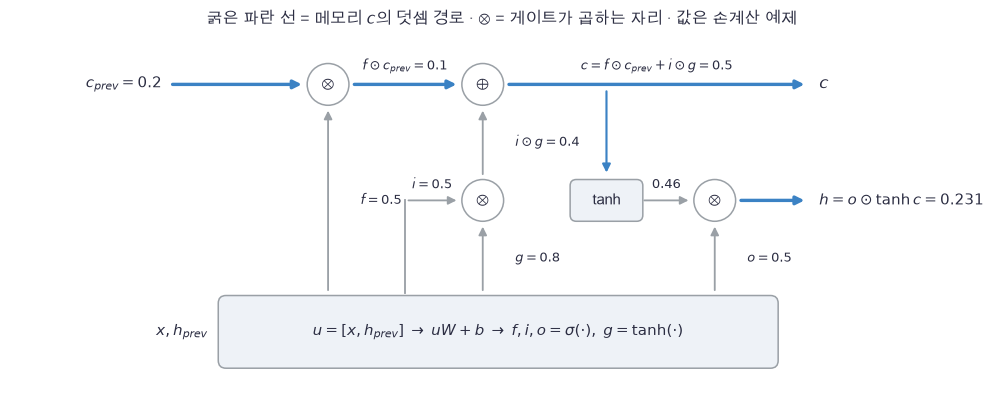

In [4]:
plot_lstm_cell(cell_values)

🔍 **확인** · 위의 굵은 파란 선이 메모리 $c$의 길입니다. 이전 메모리 0.2는 $f=0.5$를 곱해 0.1만 남고, 후보 0.8은 $i=0.5$를 곱해 0.4가 되어 **더해집니다.** 새 메모리 0.5의 tanh에 $o=0.5$를 곱한 0.231이 출력입니다.
06번의 RNN은 이 자리에서 $\tanh(\cdot)$ 하나로 상태 전체를 다시 썼습니다. 여기서는 ⊗ 자리의 계수만 바꾸면 옛 메모리를 그대로 두거나($f=1$) 완전히 지울 수($f=0$) 있습니다. 아래 상자의 affine이 그 계수를 데이터에서 만듭니다.

In [5]:
def sigmoid(z):
    """σ(z) = 1/(1 + e^−z)를 큰 |z|에서도 넘치지 않게 (02번 7절). z: 어떤 모양 → 같은 모양의 (0, 1) 값."""
    t = np.exp(-np.abs(z))                                  # e^−|z| ≤ 1
    return np.where(z >= 0, 1 / (1 + t), t / (1 + t))


def lstm_step(x, hprev, cprev, p):
    """LSTM 한 스텝: u = [x, h_prev], [a_f, a_i, a_o, a_g] = uW + b, 게이트 f, i, o = σ(·), 후보 g = tanh(·), c = f⊙c_prev + i⊙g, h = o⊙tanh(c).
    x: (N, D), hprev, cprev: (N, H), p: {"W": (D+H, 4H), "b": (4H,)} → (h, c: (N, H), cache: backward용 (u, cprev, f, i, o, g, c, D))."""
    u = np.concatenate([x, hprev], axis=1)                  # (N, D+H): 입력과 이전 출력을 옆으로 붙임
    af, ai, ao, ag = np.split(u @ p["W"] + p["b"], 4, axis=1)   # (N, H) 넷: affine 한 번의 폭 4H를 네 묶음으로. 순서 f, i, o, g
    f, i, o, g = sigmoid(af), sigmoid(ai), sigmoid(ao), np.tanh(ag)   # 게이트 셋은 (0, 1), 후보는 (−1, 1)
    c = f * cprev + i * g                                   # (N, H): 남긴 옛 메모리 + 넣은 후보
    h = o * np.tanh(c)                                      # (N, H): 메모리의 tanh에 출력 게이트
    return h, c, (u, cprev, f, i, o, g, c, x.shape[1])

In [6]:
# 쓰는 것: cell_values, cell_f, cell_i, cell_o, cell_g (1절 손계산 셀)
hand_p = {"W": np.zeros((2, 4)), "b": np.array([0., 0., 0., np.arctanh(0.8)])}   # D = H = 1: W는 (2, 4), b는 (4,). 손계산 예제와 같은 설정
hand_h, hand_c, hand_cache = lstm_step(np.zeros((1, 1)), np.zeros((1, 1)), np.array([[0.2]]), hand_p)   # x = h_prev = 0, c_prev = 0.2
# np.arctanh(0.8)는 tanh를 적용하면 0.8이 되는 입력입니다.
np.testing.assert_allclose(hand_c, 0.5 * 0.2 + 0.5 * 0.8)           # 검산: c = f·c_prev + i·g
np.testing.assert_allclose(hand_h, 0.5 * np.tanh(0.5))              # 검산: h = o·tanh(c)
print("f=i=o=0.5, g=0.8 → c=", hand_c.item(), "h=", hand_h.item())
for key in ("h", "c"):
    np.testing.assert_allclose({"h": hand_h, "c": hand_c}[key], cell_values[key])     # 검산: 위 도식의 손계산 값과 같음
np.testing.assert_allclose(hand_cache[2:6], [[[cell_f]], [[cell_i]], [[cell_o]], [[cell_g]]])   # 검산: 캐시의 f, i, o, g

f=i=o=0.5, g=0.8 → c= 0.5 h= 0.23105857863000487


🔍 **확인** · `lstm_step`이 손계산과 같은 $c=0.5$, $h=0.5\tanh(0.5)$를 냅니다. 캐시에는 $u, c_{prev}$와 네 게이트, 새 $c$, 그리고 $u$에서 $x$를 떼어 낼 폭 $D$가 들어 있습니다. backward가 이 값들을 다시 씁니다.

### ✏️ 연습 1 · 게이트는 계산한 계수

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.** `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요. 아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

입력 `x` `(N, D)`와 이전 출력 `hprev` `(N, H)`를 열 방향으로 붙인 `u`를 만들고, affine 한 번의 폭 `4H`를 네 묶음 `af, ai, ao, ag`로 나누는 두 줄을 채우세요. sigmoid·tanh를 지나 `f, i, o, g`가 되는 줄은 미리 써 두었습니다. 검사는 1절 손계산과 `W`가 0이 아닌 작은 손계산, 그리고 본문 `lstm_step`의 캐시로 합니다.

In [7]:
def exercise_lstm_gates(x, hprev, p):
    """연습 1: 입력과 이전 출력에서 세 게이트와 후보를 계산. x: (N, D), hprev: (N, H), p: {"W": (D+H, 4H), "b": (4H,)} → (f, i, o, g: 각 (N, H))."""
    assert x.shape[0] == hprev.shape[0], "x와 hprev의 행 수 N이 같아야 합니다"
    assert p["W"].shape[0] == x.shape[1] + hprev.shape[1], "W의 행 수는 D + H여야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: x와 hprev를 열 방향으로 붙인 u (N, D+H)를 만들고, affine 한 번 u @ W + b 의 폭 4H를 네 묶음 af, ai, ao, ag (각 (N, H))로 나눔
    ### 힌트: 1절 lstm_step 의 첫 두 줄입니다. 붙일 때도 나눌 때도 축은 axis=1 이고, 묶음의 순서는 f, i, o, g 입니다.
    raise NotImplementedError
    f, i, o, g = sigmoid(af), sigmoid(ai), sigmoid(ao), np.tanh(ag)   # 게이트 셋은 (0, 1), 후보는 (−1, 1)
    return f, i, o, g

In [8]:
def check_lstm_gates(candidate):
    """D = H = 1 손계산 둘과 본문 lstm_step의 캐시로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: lstm_step (1절)
    hand_p_c = {"W": np.zeros((2, 4)), "b": np.array([0., 0., 0., np.arctanh(0.8)])}     # 1절 손계산 설정: W = 0
    f_a, i_a, o_a, g_a = candidate(np.zeros((1, 1)), np.zeros((1, 1)), hand_p_c)
    np.testing.assert_allclose([f_a, i_a, o_a, g_a], [[[0.5]], [[0.5]], [[0.5]], [[0.8]]])   # 검산: 1절 손계산 f = i = o = 0.5, g = 0.8
    p_b = {"W": np.array([[1., 0., -1., 0.5], [0., 1., 0.5, -1.]]), "b": np.zeros(4)}     # (2, 4): 행 0은 x의, 행 1은 h_prev의 가중치
    f_b, i_b, o_b, g_b = candidate(np.array([[1.]]), np.array([[2.]]), p_b)
    assert f_b.shape == (1, 1), f"게이트 하나의 모양은 (N, H) = (1, 1)이어야 하는데 {f_b.shape}입니다"
    np.testing.assert_allclose([f_b, i_b, o_b, g_b], [[[1 / (1 + np.exp(-1))]], [[1 / (1 + np.exp(-2))]], [[0.5]], [[np.tanh(-1.5)]]])   # 검산: u = [1, 2] 이므로 a = [1, 2, 0, −1.5]
    rng_c = np.random.default_rng(73)
    x_c, h0_c, c0_c = [rng_c.normal(size=(3, 2)) * 0.3 for _ in range(3)]
    p_c = {"W": rng_c.normal(size=(4, 8)) * 0.3, "b": rng_c.normal(size=8) * 0.2}
    _, _, cache_ref = lstm_step(x_c, h0_c, c0_c, p_c)
    np.testing.assert_allclose(candidate(x_c, h0_c, p_c), cache_ref[2:6])               # 검산: 본문 캐시의 f, i, o, g와 같음
    print("세 게이트와 후보: 손계산·lstm_step 과 일치합니다.")

run_check(check_lstm_gates, exercise_lstm_gates, hint="u = np.concatenate([x, hprev], axis=1) · af, ai, ao, ag = np.split(u @ p[\"W\"] + p[\"b\"], 4, axis=1)")

☐ exercise_lstm_gates: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: u = np.concatenate([x, hprev], axis=1) · af, ai, ao, ag = np.split(u @ p["W"] + p["b"], 4, axis=1)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
u = np.concatenate([x, hprev], axis=1)
af, ai, ao, ag = np.split(u @ p["W"] + p["b"], 4, axis=1)
```

</details>

## 🔑 2. LSTM backward: c로 향하는 기울기를 먼저 합합니다

**이 절에서 가져갈 것:** 메모리 $c$에는 두 경로의 기울기가 옵니다. 이번 시각의 출력 $h=o\tanh(c)$를 거쳐 온 것과, 다음 시각에서 덧셈 경로를 타고 돌아온 $dc_{future}$입니다. 둘을 더한 $dc$를 $c=f\,c_{prev}+i\,g$의 네 입력으로 나누고, 게이트의 sigmoid·tanh 도함수를 곱해 affine으로 되돌립니다.

1절의 손계산 예제에서 $dh=1$, $dc_{future}=1$이 들어왔다고 합시다. $h=o\tanh(c)$이므로 $o$에는 $\tanh(c)$가, $c$에는 $o(1-\tanh^2c)$가 곱해져 돌아오고, 여기에 $dc_{future}$를 더한 것이 $dc$입니다.

> **용어** · $dc_{future}$: 다음 시각의 backward가 $c_{t+1}=f_{t+1}c_t+\cdots$의 덧셈 경로로 돌려준 $c_t$의 기울기. 06번의 `dh_next`가 $c$에도 하나 더 생긴 것입니다.

상류 입력을 $dh$, $dc_{future}$라 두면 $h=o\tanh(c)$에서
$$do=dh\odot\tanh(c),\qquad dc=dc_{future}+dh\odot o\odot(1-\tanh^2(c)).$$
$c=f c_{prev}+ig$의 네 입력으로 돌아갑니다.
$$df=dc\odot c_{prev},\quad dc_{prev}=dc\odot f,\quad di=dc\odot g,\quad dg=dc\odot i.$$
게이트의 비선형을 지나면
$$da_f=df\odot f(1-f),\quad da_i=di\odot i(1-i),\quad
 da_o=do\odot o(1-o),\quad da_g=dg\odot(1-g^2).$$
네 $da$를 forward와 같은 순서로 연결해 $dW=u^Tda$, $db=\sum_n da$, $du=daW^T$를 구합니다. $du$의 앞 $D$열은 $dx$, 뒤 $H$열은 $dh_{prev}$입니다. $dc_{prev}$는 별도의 상태 경로라서 따로 반환합니다.

아래는 손계산 예제에서 이 값들을 차례로 구한 것입니다.

> **코드**
>
> - `du[:, :D]`, `du[:, D:]`: 열을 앞 D개와 나머지로 가릅니다. forward에서 u = [x, h_prev]로 붙였으므로 거꾸로 dx와 dh_prev가 됩니다.
> - `x, h0, c0 = [rng.normal(size=(2, 2)) * 0.3 for _ in range(3)]`: 같은 모양의 난수 배열 세 개를 만들어 세 이름에 풀어 받습니다.
> - `[("x", x, dx), ("h0", h0, dh0), …, *[(k, v, grads[k]) for k, v in p.items()]]`: (이름, 원본, 기울기) 세 쌍의 목록. 별표는 파라미터마다 만든 목록을 펼쳐 이어 붙입니다(06번 2절).

In [9]:
# 쓰는 것: cell_c, cell_o, cell_cprev, cell_f, cell_i, cell_g (1절 손계산 셀)
back_dh, back_dc_future = 1.0, 1.0                                      # 상류에서 들어온 dh와 다음 시각에서 온 dc_future
back_tanhc = np.tanh(cell_c)
back_do = back_dh * back_tanhc                                          # h = o·tanh(c) 에서 o 로: do = dh·tanh(c)
back_dc = back_dc_future + back_dh * cell_o * (1 - back_tanhc ** 2)     # 두 경로를 더한 dc = dc_future + dh·o·(1 − tanh²c)
back_df, back_dcprev = back_dc * cell_cprev, back_dc * cell_f           # c = f·cprev + i·g 의 네 입력으로: df = dc·c_prev, dc_prev = dc·f
back_di, back_dg = back_dc * cell_g, back_dc * cell_i                   #   di = dc·g, dg = dc·i
back_da = [back_df * cell_f * (1 - cell_f), back_di * cell_i * (1 - cell_i),
           back_do * cell_o * (1 - cell_o), back_dg * (1 - cell_g ** 2)]  # affine 출력 네 묶음의 기울기 da (sigmoid·tanh 도함수를 곱함) = db
back_table = [back_do, back_dc, back_df, back_dcprev, back_di, back_dg]  # 그림용 표
print(f"do = {back_do:.4f} · dc = {back_dc:.4f} (h 경로 {back_dc - back_dc_future:.4f} + 미래 {back_dc_future:g}) · dc_prev = {back_dcprev:.4f}")

do = 0.4621 · dc = 1.3932 (h 경로 0.3932 + 미래 1) · dc_prev = 0.6966


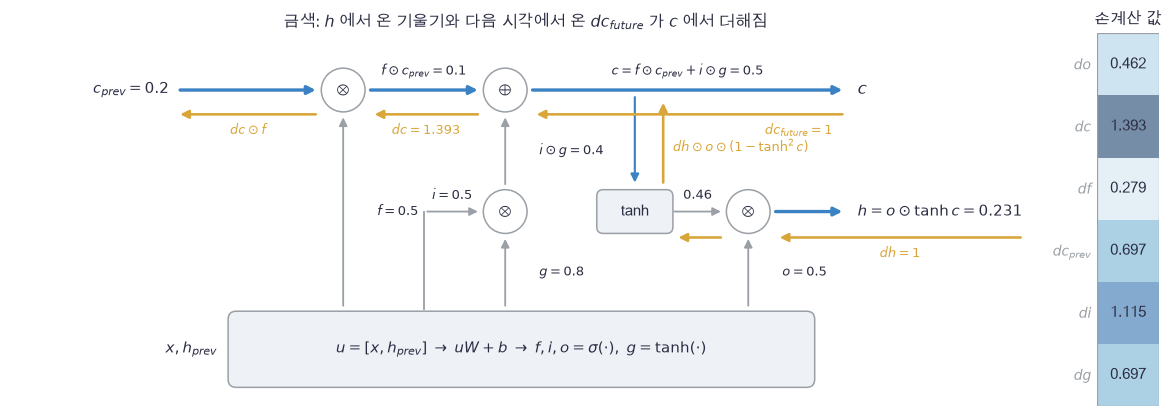

In [10]:
plot_lstm_backward(cell_values, {"dh": back_dh, "dc_future": back_dc_future, "dc": back_dc}, back_table,
                   ["$do$", "$dc$", "$df$", "$dc_{prev}$", "$di$", "$dg$"])

🔍 **확인** · 금색 화살표가 $c$에 두 개 모입니다. 출력 $h$를 거쳐 온 $dh\odot o\odot(1-\tanh^2c)$와 다음 시각에서 온 $dc_{future}$입니다. 그 합 $dc$가 왼쪽으로 가며 $f$를 곱한 만큼 $c_{prev}$로 돌아가고, $c_{prev}$를 곱한 만큼 $f$로, $g$·$i$를 곱한 만큼 $i$·$g$로 나뉩니다.
$dc_{future}$를 빼먹으면 덧셈 경로가 끊깁니다. 7절의 의도적 오답이 그 경우입니다. 아래 구현은 이 식을 배치·다차원으로 쓰고, 검산에서 손계산 값과 중심차분을 함께 봅니다.

In [11]:
def lstm_step_backward(dh, dc_future, cache, p):
    """LSTM 한 스텝 backward (위 수식 순서대로). dh, dc_future: (N, H), cache: lstm_step의 것 → (dx: (N, D), dh_prev: (N, H), dc_prev: (N, H), grads: {"W", "b"})."""
    u, cprev, f, i, o, g, c, D = cache
    tanhc = np.tanh(c)
    do = dh * tanhc                                         # do = dh ⊙ tanh(c)
    dc = dc_future + dh * o * (1 - tanhc ** 2)              # dc = dc_future + dh ⊙ o ⊙ (1 − tanh²c): 두 경로를 더함
    df, di, dg = dc * cprev, dc * g, dc * i                 # c = f c_prev + i g 의 입력으로: df = dc ⊙ c_prev, di = dc ⊙ g, dg = dc ⊙ i
    da = np.concatenate([df * f * (1 - f), di * i * (1 - i),
                         do * o * (1 - o), dg * (1 - g ** 2)], axis=1)   # (N, 4H): da_f, da_i, da_o, da_g를 forward와 같은 순서로 붙임
    du = da @ p["W"].T                                      # (N, D+H): du = da Wᵀ
    grads = {"W": u.T @ da, "b": da.sum(axis=0)}            # dW = uᵀ da, db = Σ_n da
    return du[:, :D], du[:, D:], dc * f, grads              # dx = 앞 D열, dh_prev = 뒤 H열, dc_prev = dc ⊙ f

In [12]:
def check_lstm_step(candidate):
    """한 스텝의 x·h_prev·c_prev·W·b 기울기를 중심차분과 대조합니다. 스칼라는 Σ h⊙dh + Σ c⊙dc라서 c의 별도 상류 경로까지 검사합니다. → 상대오차 사전."""
    # 쓰는 것: lstm_step (1절)
    rng = np.random.default_rng(71)
    x, h0, c0 = [rng.normal(size=(2, 2)) * 0.3 for _ in range(3)]      # (N, D), (N, H), (N, H) = (2, 2) 셋
    p = {"W": rng.normal(size=(4, 8)) * 0.3, "b": rng.normal(size=8) * 0.2}   # (D+H, 4H), (4H,)
    h, c, cache = lstm_step(x, h0, c0, p)
    dh, dc = rng.normal(size=h.shape), rng.normal(size=c.shape)         # 임의의 상류 기울기 둘
    dx, dh0, dc0, grads = candidate(dh, dc, cache, p)

    def scalar():
        """검사기용: 스칼라 L = Σ h⊙dh + Σ c⊙dc."""
        h, c, _ = lstm_step(x, h0, c0, p)
        return float(np.sum(h * dh) + np.sum(c * dc))

    errors = {}
    for name, value, grad in [("x", x, dx), ("h0", h0, dh0), ("c0", c0, dc0),
                              *[(k, v, grads[k]) for k, v in p.items()]]:
        errors[name] = rel_error(grad, numerical_gradient(scalar, value))   # value를 흔들어 잰 중심차분과 비교
        assert np.isfinite(errors[name]), f"{name}: 상대오차가 유한해야 합니다"
        assert errors[name] < 2e-6, f"{name}: 상대오차 {errors[name]:.2e}는 2e−6 아래여야 합니다"
    return errors

In [13]:
# 쓰는 것: hand_cache, hand_p (1절 검산 셀) · back_dcprev, back_da (2절 손계산 셀)
lstm_step_errors = check_lstm_step(lstm_step_backward)
print("LSTM 한 스텝 최대 상대오차:", max(lstm_step_errors.values()))
_, _, hand_dcprev, hand_grads = lstm_step_backward(np.ones((1, 1)), np.ones((1, 1)), hand_cache, hand_p)   # dh = dc_future = 1
np.testing.assert_allclose(hand_dcprev.item(), back_dcprev)              # 검산: 위 표의 dc_prev
np.testing.assert_allclose(hand_grads["b"], back_da)                     # 검산: db = 네 묶음의 da (x = h_prev = 0 이라 dW = 0)
print("손계산 예제의 dc_prev·db 가 위 표와 같습니다.")

LSTM 한 스텝 최대 상대오차: 2.1654197627094866e-10
손계산 예제의 dc_prev·db 가 위 표와 같습니다.


🔍 **확인** · 한 스텝의 $x$·$h_{prev}$·$c_{prev}$·$W$·$b$ 미분이 모두 중심차분과 $2\times10^{-6}$ 안에서 맞고, 손계산 예제의 $dc_{prev}$와 $db$도 표와 같습니다. 검사의 스칼라는 $\sum h\odot dh+\sum c\odot dc$라서 $c$의 별도 상류 경로까지 확인합니다.

### ✏️ 연습 2 · dc를 네 입력으로 나누기

두 경로를 더해 얻은 `dc` `(N, H)`를 $c=f\odot c_{prev}+i\odot g$의 네 입력으로 돌려보내는 두 줄을 채우세요. 곱셈 하나의 미분은 상대편 인자이므로 `df`, `dcprev`, `di`, `dg`는 모두 `dc`에 무언가를 곱한 것입니다. 검사는 손계산과 2절 표, 본문 `lstm_step_backward`의 `dc_prev`로 합니다.

In [14]:
def exercise_split_dc(dc, cprev, f, i, g):
    """연습 2: 합쳐진 dc를 c = f⊙c_prev + i⊙g 의 네 입력으로 나눔. dc, cprev, f, i, g: 모두 (N, H) → (df, dcprev, di, dg: 각 (N, H))."""
    assert dc.shape == cprev.shape == f.shape == i.shape == g.shape, "다섯 배열은 모두 같은 모양 (N, H)이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 곱셈 하나의 미분은 상대편 인자입니다. dc 에서 네 입력 df, dcprev, di, dg 를 각각 구함
    ### 힌트: 2절 두 번째 수식 줄(네 입력으로 돌아가는 식)이고, lstm_step_backward 에서는 df, di, dg 한 줄과 반환문의 dc_prev 자리입니다.
    raise NotImplementedError
    return df, dcprev, di, dg

In [15]:
def check_split_dc(candidate):
    """손계산 하나, 2절 손계산 표, 본문 lstm_step_backward의 dc_prev로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: back_dc, back_df, back_dcprev, back_di, back_dg (2절 손계산 셀) · lstm_step (1절) · lstm_step_backward (2절)
    one = np.ones((1, 1))
    df_a, dcprev_a, di_a, dg_a = candidate(2. * one, 0.2 * one, 0.5 * one, 0.5 * one, 0.8 * one)
    assert df_a.shape == (1, 1), f"df의 모양은 dc와 같은 (1, 1)이어야 하는데 {df_a.shape}입니다"
    np.testing.assert_allclose([df_a, dcprev_a, di_a, dg_a], [[[0.4]], [[1.0]], [[1.6]], [[1.0]]])   # 검산: dc = 2 에 상대편 인자 0.2, 0.5, 0.8, 0.5를 곱함
    hand_b = candidate(back_dc * one, 0.2 * one, 0.5 * one, 0.5 * one, 0.8 * one)
    np.testing.assert_allclose(np.ravel(hand_b), [back_df, back_dcprev, back_di, back_dg])   # 검산: 2절 손계산 표의 df, dc_prev, di, dg
    rng_c = np.random.default_rng(72)
    x_c, h0_c, c0_c = [rng_c.normal(size=(3, 2)) * 0.3 for _ in range(3)]
    p_c = {"W": rng_c.normal(size=(4, 8)) * 0.3, "b": np.zeros(8)}
    _, _, cache_ref = lstm_step(x_c, h0_c, c0_c, p_c)
    u_c, cprev_c, f_c, i_c, o_c, g_c, c_c, _ = cache_ref                                   # 캐시를 풀어 게이트와 c를 꺼냄
    dh_c, dcf_c = rng_c.normal(size=(3, 2)), rng_c.normal(size=(3, 2))
    dc_c = dcf_c + dh_c * o_c * (1 - np.tanh(c_c) ** 2)                                    # 두 경로를 더한 dc (연습 B의 식)
    _, _, dcprev_ref, _ = lstm_step_backward(dh_c, dcf_c, cache_ref, p_c)
    np.testing.assert_allclose(candidate(dc_c, cprev_c, f_c, i_c, g_c)[1], dcprev_ref)     # 검산: 본문 lstm_step_backward의 dc_prev
    print("dc 나누기: 손계산·lstm_step_backward 와 일치합니다.")

run_check(check_split_dc, exercise_split_dc, hint="df, dcprev = dc * cprev, dc * f · di, dg = dc * g, dc * i")

☐ exercise_split_dc: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: df, dcprev = dc * cprev, dc * f · di, dg = dc * g, dc * i


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
df, dcprev = dc * cprev, dc * f
di, dg = dc * g, dc * i
```

</details>

## 🔑 3. 덧셈 경로는 무엇을 보장합니까?

**이 절에서 가져갈 것:** 다른 입력을 고정하면 $c_t$에서 $c_{t-1}$로 가는 직접 경로의 미분은 $f_t$ 하나이고, $T$시각을 거슬러 가면 $\prod_t f_t$입니다. $f\approx1$이면 06번의 $w_h^T$와 달리 오래 남지만, 그것이 전체 미분은 아닙니다.

> **용어** · **직접 경로(direct path)**: $c_{t-1}\to c_t$로 게이트를 거치지 않고 곱셈 한 번만 지나는 길. 전체 Jacobian에는 $c\to h\to$다음 시각 게이트로 가는 길도 포함됩니다.

다른 입력과 게이트를 고정한 **c의 직접 경로**에서는 $\partial c_t/\partial c_{t-1}=f_t$입니다. 이 경로만 따라가면 곱은 $\prod_t f_t$입니다. $f\approx1$이면 정보를 오래 전달할 수 있지만, $f<1$의 긴 곱은 여전히 줄어듭니다.

실제 모델의 전체 미분에는 $c\to h\to$ 다음 게이트로 이어지는 경로도 있습니다. 전체 Jacobian이 언제나 $\prod f$라거나 LSTM에서 기울기 소실이 완전히 사라진다고 말하면 틀립니다. 아래 실험은 $W=0$으로 게이트를 상수로 만든 **직접 경로만의 통제 예제**입니다. 초기 메모리 1이 $t$스텝 뒤에 $f^t$만큼 남습니다.

> **코드**
>
> - `np.log(f / (1 - f))`: sigmoid의 역함수(logit). 이 값을 편향에 넣으면 forget gate가 정확히 f가 됩니다.
> - `f ** delays`: 숫자를 배열 `(40,)`로 거듭제곱하면 f¹, f², …, f⁴⁰이 한 번에 나옵니다.

In [16]:
# 쓰는 것: lstm_step (1절)
delays = np.arange(1, 41)                                  # (40,): 지난 스텝 수 t
retention = {}                                             # 그림용: 이름 → 남은 메모리 (40,)
for f in [0.5, 0.9, 0.99]:
    # log(f/(1-f))를 sigmoid에 넣으면 f가 됩니다.
    p_fixed = {"W": np.zeros((2, 4)), "b": np.array([np.log(f / (1 - f)), 0., 0., 0.])}   # W = 0: 게이트가 상수. forget만 f, 나머지 0.5, 후보 0
    c, h = np.ones((1, 1)), np.zeros((1, 1))                # 초기 메모리 1
    values = []
    for _ in delays:
        h, c, _ = lstm_step(np.zeros((1, 1)), h, c, p_fixed)   # 입력 0으로 한 스텝
        values.append(c.item())
    np.testing.assert_allclose(values, f ** delays)        # 검산: 직접 경로만 있으면 t스텝 뒤 메모리 = f^t
    retention[f"f={f}"] = values
print("검산 통과: 게이트가 상수 f이면 초기 메모리 1이 t스텝 뒤 f^t 만큼 남습니다")

검산 통과: 게이트가 상수 f이면 초기 메모리 1이 t스텝 뒤 f^t 만큼 남습니다


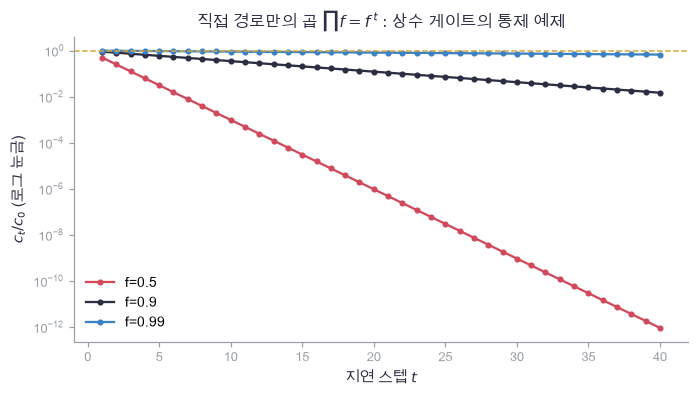

In [17]:
plot_retention(delays, retention)

🔍 **확인** · $f=0.5$면 10스텝 만에 $10^{-3}$ 아래로 사라지고, $f=0.99$면 40스텝 뒤에도 0.67이 남습니다. 06번에서 $w_h=0.7$이 25스텝 만에 $10^{-4}$가 된 것과 비교하면, **1에 가까운 게이트를 학습할 수 있다**는 점이 덧셈 경로의 이점입니다. 곱 자체가 없어진 것은 아닙니다.

### ✏️ 연습 3 · 거슬러 가며 곱하는 f

3절 실험은 forget gate가 상수 `f`였습니다. 이번에는 시각마다 다른 게이트 `f_seq` `(T,)`가 주어질 때, 마지막 메모리에서 시간을 거슬러 가며 **직접 경로의 미분**을 누적하는 반복문 안 두 줄을 쓰세요. `grad[t]`는 시각 `t`의 이전 메모리가 마지막 메모리에 미치는 미분이고, 첫 시각까지 간 `grad[0]`은 $\prod_t f_t$가 되어야 합니다.

In [18]:
def exercise_direct_path(f_seq):
    """연습 3: 직접 경로의 미분을 시간을 거슬러 누적. f_seq: (T,) 시각별 forget gate → grad: (T,), grad[t] = 시각 t의 c_prev가 마지막 메모리에 미치는 미분."""
    assert f_seq.ndim == 1, "f_seq는 시각별 forget gate를 담은 (T,) 배열이어야 합니다"
    grad = np.zeros(len(f_seq))                             # (T,): 0으로 채워 두었으니 반복문이 모두 덮어써야 합니다
    d = 1.0                                                 # 마지막 메모리의 자기 자신에 대한 미분
    for t in reversed(range(len(f_seq))):                   # 마지막 시각부터 거슬러
        ### 이 주석 아래에 다음을 구현하세요.
        ### 구현할 내용: 한 시각을 거슬러 갈 때마다 그 시각의 게이트를 지금까지의 미분 d에 곱해 새 d로 두고, 그 값을 grad[t]에 적음
        ### 힌트: 3절 본문의 직접 경로 미분 한 개(∂c_t/∂c_{t−1})를 시각마다 이어 곱하는 것입니다. 게이트가 상수 f이면 거슬러 간 스텝 수만큼의 거듭제곱이 됩니다.
        raise NotImplementedError
    return grad

In [19]:
def check_direct_path(candidate):
    """손계산 둘과 3절 실험의 f = 0.9 곡선으로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: delays, retention (3절 실험 셀)
    actual = candidate(np.array([0.5, 0.5, 0.5]))
    assert actual.shape == (3,), f"결과의 모양은 f_seq와 같은 (T,) = (3,)이어야 하는데 {actual.shape}입니다"
    np.testing.assert_allclose(actual, [0.125, 0.25, 0.5])                    # 검산: 마지막 시각만 거치면 0.5, 세 시각을 거슬러 가면 0.5^3
    varying = candidate(np.array([0.9, 0.5, 1.0, 0.2]))
    np.testing.assert_allclose(varying, [0.09, 0.1, 0.2, 0.2])                # 검산: 뒤에서부터 0.2, ·1.0, ·0.5, ·0.9. f = 1 인 시각은 미분을 그대로 넘김
    np.testing.assert_allclose(varying[0], np.prod([0.9, 0.5, 1.0, 0.2]))     # 검산: T시각을 거슬러 가면 ∏ f_t
    np.testing.assert_allclose(candidate(np.full(len(delays), 0.9))[::-1], retention["f=0.9"])   # 검산: 3절 실험의 f = 0.9 곡선과 같은 거듭제곱
    print("직접 경로의 미분: 손계산·3절 실험과 일치합니다.")

run_check(check_direct_path, exercise_direct_path, hint="d = f_seq[t] * d · grad[t] = d")

☐ exercise_direct_path: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: d = f_seq[t] * d · grad[t] = d


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
d = f_seq[t] * d
grad[t] = d
```

</details>

## 🔑 4. GRU: 상태 하나에 남길 값과 새 값을 섞기

**이 절에서 가져갈 것:** GRU는 메모리 $c$ 없이 $h=z\odot h_{prev}+(1-z)\odot g$로 옛 상태와 새 후보를 **한 계수로 섞습니다.** $z$가 1이면 그대로 두고 0이면 후보로 바꿉니다. 후보를 만들 때는 reset $r$로 옛 상태를 얼마나 쓸지 정합니다.

수첩 하나만 들고 가되, 페이지마다 "옛 내용을 $z$만큼 남기고 새 내용을 $1-z$만큼 적는다"고 정하는 셈입니다. LSTM의 $f$와 $i$가 하나의 $z$로 묶인 꼴입니다.

> **용어**
>
> - **update gate** $z$: 이전 상태를 유지하는 비율. 이 노트북은 Cho 등의 관례를 따라 **$z$가 클수록 이전 상태를 유지**합니다.
> - **reset gate** $r$: 후보 $g$를 만들 때 이전 상태에 곱하는 계수. 0이면 후보가 입력만 봅니다. 여기서는 곱한 뒤 affine에 넣는 **reset-before** 형태입니다.

GRU에는 별도의 $c$가 없습니다.
$$z=\sigma([x,h_{prev}]W_z+b_z),\quad r=\sigma([x,h_{prev}]W_r+b_r),$$
$$q=[x,r\odot h_{prev}],\quad g=\tanh(qW_g+b_g),\quad
h=z\odot h_{prev}+(1-z)\odot g.$$

두 게이트는 LSTM처럼 $[x, h_{prev}]$의 affine+sigmoid이고, 후보는 reset을 곱한 옛 상태와 입력을 붙인 $q$의 affine+tanh입니다. 새 상태는 옛 상태와 후보의 가중 평균입니다.

reset $r$는 후보를 만들 때 과거 상태를 얼마나 사용할지 조절합니다. 어떤 자료는 z의 역할을 반대로 정의하거나 reset을 행렬곱 뒤에 곱합니다. **기호 이름 대신 실제 수식과 곱 순서**를 비교해야 합니다.

Backward를 곱·덧셈 순서대로 쓰면
$$dz=dh\odot(h_{prev}-g),\quad dg=dh\odot(1-z),\quad dh_{prev}^{direct}=dh\odot z.$$
후보의 tanh와 affine을 거쳐 얻은 $dq_h$에 대해 $dr=dq_h\odot h_{prev}$, $dh_{prev}^{candidate}=dq_h\odot r$입니다. 여기에 z·r의 affine 경로에서 온 $dh_{prev}$를 더해야 합니다. $h_{prev}$로 가는 길이 세 갈래(직접·후보·게이트)라서 셋을 모두 더합니다.

아래는 $h_{prev}=0.8$, $g=-0.4$일 때 $z$에 따라 새 상태가 어디에 놓이는지입니다.

> **코드**
>
> - `q = np.concatenate([x, r * hprev], axis=1)`: 후보용 입력. reset을 곱한 옛 상태를 입력 옆에 붙입니다(reset-before).
> - `dq[:, D:]`: dq의 뒤 H열, 곧 `r * hprev` 자리로 돌아온 기울기. 여기서 dr(= × hprev)과 h_prev의 후보 경로 기울기(= × r)가 갈라집니다.
> - `{key: value for gate in ["z", "r", "g"] for key, value in [("W" + gate, …), ("b" + gate, …)]}`: 게이트 이름마다 W와 b 두 항목을 만드는 이중 사전 컴프리헨션. 키는 "Wz", "bz", "Wr", "br", "Wg", "bg"입니다.

In [20]:
mix_hprev, mix_g = 0.8, -0.4                                    # 이전 상태와 후보
mix_z = np.array([0., 0.25, 0.5, 0.75, 1.])                     # (5,): update gate 다섯 가지
mix_h = mix_z * mix_hprev + (1 - mix_z) * mix_g                 # (5,): z 마다의 새 상태 h = z·h_prev + (1 − z)·g
print("z =", mix_z, "→ h =", mix_h)

z = [0.   0.25 0.5  0.75 1.  ] → h = [-0.4 -0.1  0.2  0.5  0.8]


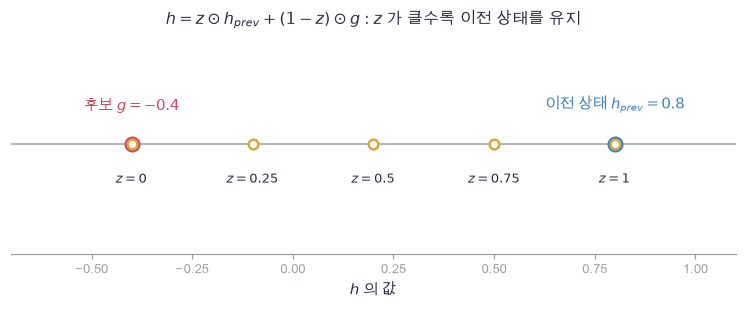

In [21]:
plot_gru_mix(mix_z, mix_hprev, mix_g, mix_h)

🔍 **확인** · 새 상태는 언제나 후보 $g$와 이전 상태 $h_{prev}$ 사이에 놓입니다. $z=1$이면 이전 상태 그대로(정보 유지), $z=0$이면 후보로 완전히 교체입니다. LSTM은 이 두 계수를 $f$와 $i$로 따로 두어 합이 1이 아닐 수 있었습니다.
아래 구현은 GRU의 forward·backward, 두 구조의 초기화, GRU 검사기를 한 셀에 둡니다. 검산에는 $W=0$이면 $z=r=0.5$, $g=0$이라 $h=0.5h_{prev}$가 되는 손계산도 들어 있습니다.

In [22]:
def gru_step(x, hprev, p):
    """GRU 한 스텝: z = σ([x, h_prev]W_z + b_z), r = σ([x, h_prev]W_r + b_r), g = tanh([x, r⊙h_prev]W_g + b_g), h = z⊙h_prev + (1−z)⊙g.
    x: (N, D), hprev: (N, H), p: {"Wz", "bz", "Wr", "br", "Wg", "bg"} → (h: (N, H), cache: (u, q, hprev, z, r, g, D))."""
    # 쓰는 것: sigmoid (1절)
    u = np.concatenate([x, hprev], axis=1)                  # (N, D+H): 게이트용 입력
    z = sigmoid(u @ p["Wz"] + p["bz"])                      # (N, H): update gate
    r = sigmoid(u @ p["Wr"] + p["br"])                      # (N, H): reset gate
    q = np.concatenate([x, r * hprev], axis=1)              # (N, D+H): 후보용 입력. 옛 상태에 reset을 곱함
    g = np.tanh(q @ p["Wg"] + p["bg"])                      # (N, H): 후보
    h = z * hprev + (1 - z) * g                             # (N, H): 옛 상태와 후보의 가중 평균
    return h, (u, q, hprev, z, r, g, x.shape[1])

In [23]:
def gru_step_backward(dh, cache, p):
    """GRU 한 스텝 backward. h_prev로 가는 세 갈래(직접·후보·게이트)를 모두 더합니다.
    dh: (N, H), cache: gru_step의 것 → (dx: (N, D), dh_prev: (N, H), grads: p와 같은 키)."""
    u, q, hprev, z, r, g, D = cache
    dz, dg = dh * (hprev - g), dh * (1 - z)                 # h = z h_prev + (1−z) g 에서: dz = dh ⊙ (h_prev − g), dg = dh ⊙ (1 − z)
    dag = dg * (1 - g ** 2)                                 # 후보의 tanh 도함수: da_g = dg ⊙ (1 − g²)
    dq = dag @ p["Wg"].T                                    # (N, D+H): 후보 affine의 입력 q로
    dr = dq[:, D:] * hprev                                  # q의 뒤 H열은 r ⊙ h_prev 자리: dr = dq_h ⊙ h_prev
    dar, daz = dr * r * (1 - r), dz * z * (1 - z)           # 두 게이트의 sigmoid 도함수
    du = dar @ p["Wr"].T + daz @ p["Wz"].T                  # (N, D+H): 게이트 affine 둘의 입력 u로 (같은 u라 더함)
    dx = dq[:, :D] + du[:, :D]                              # x로 가는 두 길: 후보 경로 + 게이트 경로
    dhprev = dh * z + dq[:, D:] * r + du[:, D:]             # h_prev로 가는 세 길: 직접(dh ⊙ z) + 후보(dq_h ⊙ r) + 게이트(du의 뒤 H열)
    grads = {"Wz": u.T @ daz, "bz": daz.sum(axis=0), "Wr": u.T @ dar, "br": dar.sum(axis=0),
             "Wg": q.T @ dag, "bg": dag.sum(axis=0)}        # 세 affine의 dW = 입력ᵀ da, db = Σ_n da
    return dx, dhprev, grads

In [24]:
def init_gates(kind, D, H, seed):
    """LSTM 또는 GRU 파라미터 사전을 난수로. LSTM: W (D+H, 4H)와 b (4H,), forget 편향 1. GRU: Wz·Wr·Wg (D+H, H)와 bz·br·bg (H,)."""
    rng = np.random.default_rng(seed)
    if kind == "LSTM":
        W = rng.normal(size=(D + H, 4 * H)) / np.sqrt(D + H)
        b = np.zeros(4 * H)
        b[:H] = 1.  # 입력·상태의 affine 항이 0일 때 forget gate가 sigmoid(1)
        return {"W": W, "b": b}
    return {key: value for gate in ["z", "r", "g"]                       # 게이트 이름마다
            for key, value in [("W" + gate, rng.normal(size=(D + H, H)) / np.sqrt(D + H)),   # W와
                               ("b" + gate, np.zeros(H))]}                                   # b 두 항목

In [25]:
def check_gru_step(candidate):
    """GRU 한 스텝의 x·h_prev·여섯 파라미터 기울기를 중심차분과 대조합니다. → 상대오차 사전."""
    rng = np.random.default_rng(74)
    x, h0 = rng.normal(size=(2, 2)), rng.normal(size=(2, 3))            # (N, D), (N, H)
    p = init_gates("GRU", 2, 3, 75)
    h, cache = gru_step(x, h0, p)
    dh = rng.normal(size=h.shape)                                       # 임의의 상류 기울기
    dx, dh0, grads = candidate(dh, cache, p)

    def scalar():
        """검사기용: 스칼라 L = Σ h ⊙ dh."""
        return float(np.sum(gru_step(x, h0, p)[0] * dh))

    errors = {}
    for name, value, grad in [("x", x, dx), ("h0", h0, dh0), *[(k, v, grads[k]) for k, v in p.items()]]:
        errors[name] = rel_error(grad, numerical_gradient(scalar, value))
        assert np.isfinite(errors[name]), f"{name}: 상대오차가 유한해야 합니다"
        assert errors[name] < 2e-6, f"{name}: 상대오차 {errors[name]:.2e}는 2e−6 아래여야 합니다"
    return errors

In [26]:
# 쓰는 것: gru_step, init_gates (4절)
gru_step_errors = check_gru_step(gru_step_backward)
print("GRU 한 스텝 최대 상대오차:", max(gru_step_errors.values()))
# W=0, bias=0이면 z=r=0.5, g=0이므로 h=0.5*hprev입니다.
zero_gru = {k: np.zeros_like(v) for k, v in init_gates("GRU", 1, 1, 0).items()}   # 같은 키에 모두 0
np.testing.assert_allclose(gru_step(np.array([[3.]]), np.array([[0.8]]), zero_gru)[0], 0.4)   # 검산: h = 0.5·0.8 + 0.5·0
print("GRU z가 이전 상태를 유지하는 손계산 통과")

GRU 한 스텝 최대 상대오차: 9.456371417325128e-10
GRU z가 이전 상태를 유지하는 손계산 통과


🔍 **확인** · GRU 한 스텝의 $x$·$h_0$·여섯 파라미터 미분이 중심차분과 맞습니다. $W=0$ 손계산에서 $z=0.5$, $g=0$이므로 새 상태는 위 그림의 $z=0.5$ 점처럼 이전 상태의 절반입니다.

### ✏️ 연습 4 · reset을 거친 후보

reset gate `r` `(N, H)`로 옛 상태를 얼마나 쓸지 정한 뒤 후보 `g`를 만드는 두 줄을 채우세요. 게이트용 입력 `u`와 달리 옛 상태에는 `r`를 먼저 곱해서 입력 `x` 옆에 붙입니다(reset-before). 검사는 손계산(`r = 0.5`와 `r = 0`)과 본문 `gru_step`의 캐시로 합니다.

In [27]:
def exercise_gru_candidate(x, hprev, r, p):
    """연습 4: reset을 거친 GRU 후보. x: (N, D), hprev, r: (N, H), p: {"Wg": (D+H, H), "bg": (H,)} → g: (N, H)."""
    assert hprev.shape == r.shape, "hprev와 r는 같은 모양 (N, H)이어야 합니다"
    assert p["Wg"].shape[0] == x.shape[1] + hprev.shape[1], "Wg의 행 수는 D + H여야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: reset을 곱한 옛 상태를 입력 옆에 붙인 후보용 입력 q (N, D+H)와, 그 affine에 tanh를 씌운 후보 g
    ### 힌트: 4절 gru_step 의 q, g 두 줄(reset-before)입니다. 게이트용 u 와 달리 옛 상태에 r 를 먼저 곱해서 붙입니다.
    raise NotImplementedError
    return g

In [28]:
def check_gru_candidate(candidate):
    """D = H = 1 손계산 둘과 본문 gru_step의 캐시로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: gru_step, init_gates (4절)
    p_a = {"Wg": np.array([[1.], [2.]]), "bg": np.zeros(1)}                                # (2, 1): 행 0은 x의, 행 1은 r⊙h_prev의 가중치
    g_half = candidate(np.array([[1.]]), np.array([[0.8]]), np.array([[0.5]]), p_a)
    assert g_half.shape == (1, 1), f"후보의 모양은 (N, H) = (1, 1)이어야 하는데 {g_half.shape}입니다"
    np.testing.assert_allclose(g_half, [[np.tanh(1.8)]])                                    # 검산: q = [1, 0.5·0.8] 이므로 1·1 + 0.4·2 = 1.8
    np.testing.assert_allclose(candidate(np.array([[1.]]), np.array([[0.8]]), np.array([[0.]]), p_a), [[np.tanh(1.0)]])   # 검산: r = 0 이면 후보가 입력만 봄
    rng_c = np.random.default_rng(74)
    x_c, h0_c = rng_c.normal(size=(2, 2)), rng_c.normal(size=(2, 3))
    p_c = init_gates("GRU", 2, 3, 75)
    _, cache_ref = gru_step(x_c, h0_c, p_c)
    np.testing.assert_allclose(candidate(x_c, h0_c, cache_ref[4], p_c), cache_ref[5])      # 검산: 캐시의 r로 본문의 g
    print("reset을 거친 후보: 손계산·gru_step 과 일치합니다.")

run_check(check_gru_candidate, exercise_gru_candidate, hint="q = np.concatenate([x, r * hprev], axis=1) · g = np.tanh(q @ p[\"Wg\"] + p[\"bg\"])")

☐ exercise_gru_candidate: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: q = np.concatenate([x, r * hprev], axis=1) · g = np.tanh(q @ p["Wg"] + p["bg"])


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
q = np.concatenate([x, r * hprev], axis=1)
g = np.tanh(q @ p["Wg"] + p["bg"])
```

</details>

## 🔑 5. 한 스텝을 시간에 펼치기

**이 절에서 가져갈 것:** 06번과 같은 시간 반복입니다. forward는 시각마다 한 스텝 함수를 부르며 상태를 넘기고, backward는 마지막 시각부터 `dH[:, t] + dh`, `dC[:, t] + dc`처럼 **직접 온 기울기와 미래에서 온 기울기를 더해** 한 스텝 backward에 넣고 공유 파라미터의 미분을 누적합니다.

> **용어** · **공통 반복 인터페이스**: LSTM과 GRU를 같은 `gated_forward`·`gated_backward`로 돌리기 위한 약속. GRU에는 $c$가 없으므로 `Cs`, `dC`는 0을 채운 자리이며 학습 변수가 아닙니다.

`Hs[:,t]`, `Cs[:,t]`는 그 입력을 읽은 **뒤**의 상태입니다. 초기 상태는 따로 받아 첫 스텝에 전달합니다. `caches[t]`는 해당 스텝에서 backward에 필요한 배열을 보관합니다. 마지막 시각부터 돌아오면서 공유 파라미터의 미분을 누적합니다.

학습은 마지막 h만 사용하지만, 검사는 모든 h·c에 직접 손실을 붙입니다. 그래야 중간 상태 경로나 c의 상류 기울기를 빼먹는 오류를 잡을 수 있습니다.

아래는 7 이미지를 28행 시퀀스로 읽는 학습 전 LSTM입니다. 1절의 `lstm_step`을 시각마다 부르며 $h_t$, $c_t$, $f_t$를 모읍니다.

> **코드**
>
> - `H = p["W"].shape[1] // 4 if kind == "LSTM" else p["Wz"].shape[1]`: 조건식. LSTM은 W의 폭 4H에서, GRU는 Wz의 폭에서 상태 폭 H를 읽습니다.
> - `h0.copy()`: 초기 상태의 복사본. 반복문이 h를 덮어써도 넘겨받은 배열은 그대로입니다.
> - `caches[0][-1]`: 첫 시각 캐시의 마지막 항목 = 입력 폭 D. 두 스텝 함수 모두 캐시 끝에 D를 넣어 두었습니다.
> - `step_fn=None` 뒤 `if step_fn is None:`: 인자를 안 주면 kind에 맞는 backward를 고릅니다. 7절의 오답 검사처럼 다른 함수를 끼울 수 있습니다.
> - `all(np.isfinite(e) and e < 2e-6 for e in errors.values())`: 모든 오차가 조건을 만족하는지 한 번에.

In [29]:
# 쓰는 것: mnist_7 (📎 데이터 셀) · lstm_step (1절) · init_gates (4절)
seq_p = init_gates("LSTM", 28, 8, 70)                          # D = 28, H = 8, forget bias 1
seq_h, seq_c = np.zeros((1, 8)), np.zeros((1, 8))              # 초기 상태 (N = 1)
seq_H, seq_C, seq_F = np.zeros((28, 8)), np.zeros((28, 8)), np.zeros((28, 8))   # 시각별 h, c, f를 모을 띠
for t in range(28):
    seq_h, seq_c, seq_cache = lstm_step(mnist_7[t][None], seq_h, seq_c, seq_p)   # 같은 파라미터를 매 시각 다시 씀. 행 t를 (1, 28)로
    seq_H[t], seq_C[t], seq_F[t] = seq_h[0], seq_c[0], seq_cache[2][0]           # 캐시의 세 번째 항목이 f
seq_mark = 8                                                   # 그림에서 표시할 시각
print("h", seq_H.shape, "· c 의 범위", seq_C.min().round(2), seq_C.max().round(2), "· f 의 범위", seq_F.min().round(2), seq_F.max().round(2))

h (28, 8) · c 의 범위 -0.45 0.66 · f 의 범위 0.46 0.82


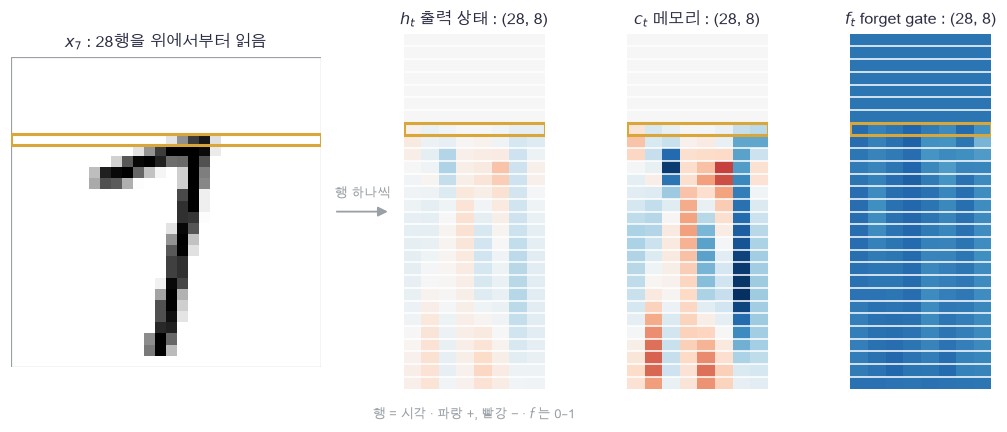

In [30]:
plot_gated_sequence(mnist_7, seq_H, seq_C, seq_F, seq_mark)

🔍 **확인** · 메모리 $c_t$는 덧셈으로 이어져 시각이 지나며 값이 쌓이고, $h_t$는 tanh와 출력 게이트를 지나 $-1$과 $1$ 사이에 머뭅니다. forget gate $f_t$는 초기 bias 1 덕분에 대체로 0.7 근처(파랑)이며 입력에 따라 조금씩 다릅니다.
학습 전이라 의미는 없지만, **두 상태가 다른 범위와 다른 규칙으로 움직인다**는 구조가 보입니다. 아래 구현은 이 반복을 배치·GRU까지 포함하는 공통 함수로 씁니다.

In [31]:
def gated_forward(X, p, kind, h0=None, c0=None):
    """LSTM·GRU 공통 forward: 시각마다 한 스텝 함수를 부르며 상태를 넘깁니다.
    X: (N, T, D), p: init_gates의 사전, kind: "LSTM" | "GRU", h0, c0: (N, H) 또는 None(0) → (Hs, Cs: (N, T, H), caches: 시각별 캐시 목록). GRU의 Cs는 0."""
    # 쓰는 것: lstm_step (1절) · gru_step (4절)
    assert kind in ("LSTM", "GRU"), "kind는 LSTM 또는 GRU"
    N, T, _ = X.shape
    H = p["W"].shape[1] // 4 if kind == "LSTM" else p["Wz"].shape[1]   # 상태 폭
    h = np.zeros((N, H)) if h0 is None else h0.copy()
    c = np.zeros((N, H)) if c0 is None else c0.copy()
    Hs, Cs = np.zeros((N, T, H)), np.zeros((N, T, H))       # 입력을 읽은 뒤의 상태들
    caches = []
    for t in range(T):
        if kind == "LSTM":
            h, c, cache = lstm_step(X[:, t], h, c, p)
            Cs[:, t] = c
        else:
            h, cache = gru_step(X[:, t], h, p)
        Hs[:, t] = h
        caches.append(cache)
    return Hs, Cs, caches

In [32]:
def gated_backward(dH, dC, caches, p, kind, step_fn=None):
    """LSTM·GRU 공통 backward: 마지막 시각부터 직접 온 기울기(dH[:, t], dC[:, t])와 미래에서 온 기울기(dh, dc)를 더해 한 스텝 backward에 넣고 파라미터 미분을 누적합니다.
    dH, dC: (N, T, H), caches: gated_forward의 것 → (dX: (N, T, D), dh0, dc0: (N, H), grads: p와 같은 키)."""
    # 쓰는 것: lstm_step_backward (2절) · gru_step_backward (4절)
    if step_fn is None:
        step_fn = lstm_step_backward if kind == "LSTM" else gru_step_backward
    N, T, H = dH.shape
    D = caches[0][-1]                                       # 캐시 끝의 입력 폭
    dX = np.zeros((N, T, D))
    dh, dc = np.zeros((N, H)), np.zeros((N, H))             # 미래에서 돌아온 기울기. 마지막 시각은 0
    grads = {k: np.zeros_like(v) for k, v in p.items()}     # 시각마다 더할 자리
    if kind == "GRU":
        assert np.all(dC == 0), "GRU에는 별도의 c 상태가 없습니다"
    for t in reversed(range(T)):                            # 마지막 시각부터
        if kind == "LSTM":
            dX[:, t], dh, dc, local = step_fn(dH[:, t] + dh, dC[:, t] + dc, caches[t], p)   # 두 상태 모두 직접 + 미래
        else:
            dX[:, t], dh, local = step_fn(dH[:, t] + dh, caches[t], p)
        for key in grads:
            grads[key] += local[key]                        # 공유 파라미터: 시각별 기여를 더함
    return dX, dh, dc, grads

In [33]:
def check_gated_sequence(kind, step_fn=None):
    """3스텝 시퀀스에서 X·초기 상태·모든 파라미터의 기울기를 중심차분과 대조합니다. 모든 h·c에 직접 손실을 붙입니다. → 상대오차 사전."""
    # 쓰는 것: init_gates (4절)
    rng = np.random.default_rng(76)
    X = rng.normal(size=(1, 3, 2)) * 0.3                   # (N, T, D)
    h0, c0 = rng.normal(size=(1, 2)) * 0.2, rng.normal(size=(1, 2)) * 0.2   # 0이 아닌 초기 상태
    p = init_gates(kind, 2, 2, 77)
    H, C, caches = gated_forward(X, p, kind, h0, c0)
    dH = rng.normal(size=H.shape)                          # 모든 시각의 h에 상류 기울기
    dC = rng.normal(size=C.shape) if kind == "LSTM" else np.zeros_like(C)   # LSTM은 c에도
    dx, dh0, dc0, grads = gated_backward(dH, dC, caches, p, kind, step_fn)

    def scalar():
        """검사기용: 스칼라 L = Σ H⊙dH + Σ C⊙dC."""
        H, C, _ = gated_forward(X, p, kind, h0, c0)
        return float(np.sum(H * dH) + np.sum(C * dC))

    entries = [("X", X, dx), ("h0", h0, dh0)] + [(k, v, grads[k]) for k, v in p.items()]   # (이름, 원본, 기울기)
    if kind == "LSTM":
        entries.append(("c0", c0, dc0))
    errors = {k: rel_error(g, numerical_gradient(scalar, v)) for k, v, g in entries}
    assert all(np.isfinite(e) and e < 2e-6 for e in errors.values()), f"모든 상대오차가 2e−6 아래여야 합니다: {errors}"
    return errors

In [34]:
# 쓰는 것: mnist_7 (📎 데이터 셀) · seq_p, seq_H, seq_C (5절 그림 셀)
sequence_errors = {kind: check_gated_sequence(kind) for kind in ["LSTM", "GRU"]}   # 두 구조 모두 검사
for kind, errors in sequence_errors.items():
    print(kind, "3스텝 전체 미분 최대 상대오차:", max(errors.values()))
seq_Hs, seq_Cs, _ = gated_forward(mnist_7[None], seq_p, "LSTM")           # 7 시퀀스를 배치 1개로
np.testing.assert_allclose(seq_Hs[0], seq_H)                              # 검산: 위 그림의 h 띠와 같은 값
np.testing.assert_allclose(seq_Cs[0], seq_C)                              # 검산: c 띠도 같음

LSTM 3스텝 전체 미분 최대 상대오차: 3.5503516229952927e-10
GRU 3스텝 전체 미분 최대 상대오차: 2.7197200291553925e-09


🔍 **확인** · 3스텝 전체의 $X$·초기 상태·모든 파라미터 미분이 두 구조 모두 중심차분과 맞고, 위 그림의 7 시퀀스 상태도 같은 함수가 냅니다.

### ✏️ 연습 5 · 직접 온 기울기와 미래에서 온 기울기

LSTM 시간 반복의 backward에서 시각 `t`의 한 스텝을 부르는 한 줄을 채우세요. 그 시각에 직접 온 `dH[:, t]`, `dC[:, t]`와 미래에서 돌아온 `dh`, `dc`를 **더해** `lstm_step_backward`에 넣고, 돌아온 `dh_prev`, `dc_prev`를 다음 반복의 `dh`, `dc`로 둡니다. 파라미터 미분을 누적하는 줄은 미리 써 두었습니다.

In [35]:
def exercise_lstm_unroll_backward(dH, dC, caches, p):
    """연습 5: LSTM 시간 반복의 backward. dH, dC: (N, T, H), caches: 시각별 lstm_step 캐시 목록, p: {"W", "b"} → (dh0, dc0: (N, H), grads: {"W", "b"})."""
    assert dH.shape == dC.shape, "dH와 dC는 같은 모양 (N, T, H)이어야 합니다"
    assert len(caches) == dH.shape[1], "캐시는 시각 T개만큼 있어야 합니다"
    N, T, H = dH.shape
    dh, dc = np.zeros((N, H)), np.zeros((N, H))             # 미래에서 돌아온 기울기. 마지막 시각은 0
    grads = {key: np.zeros_like(value) for key, value in p.items()}   # 시각마다 더할 자리
    for t in reversed(range(T)):                            # 마지막 시각부터
        ### 이 주석 아래에 다음을 구현하세요.
        ### 구현할 내용: 시각 t에 직접 온 dH[:, t]·dC[:, t]와 미래에서 온 dh·dc를 각각 더해 한 스텝 backward에 넣기
        ### 구현할 내용(이어서): 돌아온 dh_prev·dc_prev를 다음 반복의 dh·dc로, 파라미터 미분은 local로 받기 (dx는 쓰지 않음)
        ### 힌트: 5절 gated_backward 의 LSTM 가지 한 줄입니다. lstm_step_backward(dh, dc_future, cache, p) 는 (dx, dh_prev, dc_prev, grads) 를 돌려줍니다.
        raise NotImplementedError
        for key in grads:
            grads[key] += local[key]                        # 공유 파라미터: 시각별 기여를 더함
    return dh, dc, grads

In [36]:
def check_lstm_unroll_backward(candidate):
    """T = 1 손계산(2절 표)과 3스텝 시퀀스에서 본문 gated_backward와 비교합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: hand_cache, hand_p (1절 검산 셀) · back_dcprev, back_da (2절 손계산 셀) · init_gates (4절) · gated_forward, gated_backward (5절)
    dh0_a, dc0_a, grads_a = candidate(np.ones((1, 1, 1)), np.ones((1, 1, 1)), [hand_cache], hand_p)   # T = 1, dh = dc = 1
    assert dc0_a.shape == (1, 1), f"dc0의 모양은 (N, H) = (1, 1)이어야 하는데 {dc0_a.shape}입니다"
    np.testing.assert_allclose(dc0_a.item(), back_dcprev)                    # 검산: 2절 표의 dc_prev
    np.testing.assert_allclose(grads_a["b"], back_da)                        # 검산: db = 네 묶음의 da
    rng_c = np.random.default_rng(76)
    X_c = rng_c.normal(size=(2, 3, 2)) * 0.3                                 # (N, T, D)
    p_c = init_gates("LSTM", 2, 2, 77)
    _, _, caches_c = gated_forward(X_c, p_c, "LSTM")
    dH_c, dC_c = rng_c.normal(size=(2, 3, 2)), rng_c.normal(size=(2, 3, 2))   # 모든 시각의 h, c에 상류 기울기
    dh0_b, dc0_b, grads_b = candidate(dH_c, dC_c, caches_c, p_c)
    _, dh0_ref, dc0_ref, grads_ref = gated_backward(dH_c, dC_c, caches_c, p_c, "LSTM")
    np.testing.assert_allclose(dh0_b, dh0_ref)                               # 검산: 본문 gated_backward의 dh0
    np.testing.assert_allclose(dc0_b, dc0_ref)                               # 검산: dc0
    np.testing.assert_allclose(grads_b["W"], grads_ref["W"])                 # 검산: 시각별 기여를 더한 dW
    np.testing.assert_allclose(grads_b["b"], grads_ref["b"])                 # 검산: db
    print("시간 반복 backward: 손계산·gated_backward 와 일치합니다.")

run_check(check_lstm_unroll_backward, exercise_lstm_unroll_backward, hint="_, dh, dc, local = lstm_step_backward(dH[:, t] + dh, dC[:, t] + dc, caches[t], p)")

☐ exercise_lstm_unroll_backward: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: _, dh, dc, local = lstm_step_backward(dH[:, t] + dh, dC[:, t] + dc, caches[t], p)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
_, dh, dc, local = lstm_step_backward(dH[:, t] + dh, dC[:, t] + dc, caches[t], p)
```

</details>

## 🔑 6. 완성 실험: 처음의 부호를 12스텝 뒤에 답하기

**이 절에서 가져갈 것:** 첫 시각에만 정보가 있고 나머지는 잡음인 시퀀스에서, 마지막 상태의 head로 그 정보를 답합니다. 손실은 02번의 이진 CE이고 clipping·Adam은 06번과 같습니다. 성공하려면 게이트가 첫 시각의 신호를 메모리에 넣고 11시각 동안 지키고 있어야 합니다.

> **용어** · **이진 CE(BCE with logits)**: $L=\frac1N\sum_n[\log(1+e^{z_n})-y_nz_n]$, $dz=(\sigma(z)-y)/N$. 02번의 BCE를 logit에서 바로 계산하는 안정한 꼴입니다.

입력은 `(N,T,2)`입니다. 첫 채널에는 첫 시각의 ±1 신호와 이후 작은 잡음이 들어갑니다. 두 번째 채널은 첫 시각에만 1인 쓰기 표시입니다. 마지막 h에 선형 head를 붙여 처음 신호가 양수인지 예측합니다.

훈련 96개와 검증 64개는 별도 난수로 생성합니다. 모든 시퀀스 길이는 12입니다. 이 작은 실험은 게이트·상태·손실의 연결을 확인하며, 임의 길이 기억 능력이나 두 구조의 성능 순위를 증명하지 않습니다. 동일한 폭이어도 LSTM은 네 묶음, GRU는 세 묶음의 가중치를 가지므로 파라미터 수도 다릅니다.

아래는 그 데이터의 모양을 손으로 만든 두 예입니다.

> **코드**
>
> - `2 * y - 1`: 라벨 0/1을 −1/+1 신호로. `y[:, None]`: `(N,)`을 `(N, 1)`로 세워 logit `(N, 1)`과 모양을 맞춥니다.
> - `vl, vz, *_ = memory_loss(…)`: 다섯 값 중 앞 둘만 받고 나머지는 `*_`로 버립니다.
> - `for params, gradients, state in zip([p, head], [grads, dhead], states)`: RNN 파라미터와 head를 각자의 기울기·Adam 상태와 짝지어 같은 갱신을 두 번 합니다.
> - `sum(v.size for v in [*p.values(), *head.values()])`: 두 사전의 모든 배열 원소 수를 더한 파라미터 수.
> - `set(np.unique(a)) == {-1., 1.}`: 배열에 나오는 서로 다른 값이 정확히 −1과 1뿐인지.

In [37]:
rng_demo = np.random.default_rng(700)
demo_X = np.zeros((2, 12, 2))                                  # (N, T, 채널 2)
demo_X[:, :, 0] = rng_demo.normal(0, 0.12, (2, 12))          # 신호 채널: 작은 잡음
demo_X[0, 0, 0], demo_X[1, 0, 0] = 1., -1.                    # 첫 시각의 ±1 신호
demo_X[:, 0, 1] = 1.                                          # 쓰기 표시: 첫 시각에만 1
demo_y = [1, 0]                                               # 신호가 양수면 1
print("입력", demo_X.shape, "· 첫 시각", demo_X[:, 0], "· 이후 신호 채널의 크기 최대", np.abs(demo_X[:, 1:, 0]).max().round(2))

입력 (2, 12, 2) · 첫 시각 [[ 1.  1.]
 [-1.  1.]] · 이후 신호 채널의 크기 최대 0.31


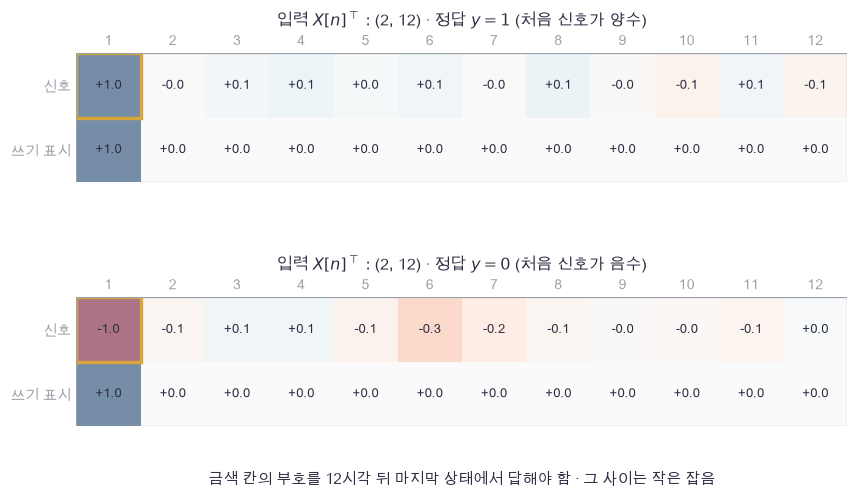

In [38]:
plot_memory_examples([demo_X[0].T, demo_X[1].T], demo_y)

🔍 **확인** · 정답은 금색 칸의 부호 하나로 정해지고, 나머지 11시각은 크기 0.1 남짓의 잡음뿐입니다. 06번의 RNN이라면 이 부호가 11번의 $\tanh(\cdot W_h)$를 거쳐 흐려질 수 있습니다. 게이트가 첫 시각에 "쓰기 표시"를 보고 메모리에 넣은 뒤 $f\approx1$로 지키면 됩니다.
아래 구현은 데이터 생성, 손실·head, Adam, 학습 루프입니다.

In [39]:
def memory_data(n, T, seed):
    """지연 기억 데이터 n개: 첫 시각의 ±1 신호(채널 0)와 쓰기 표시(채널 1), 이후는 잡음. → (X: (n, T, 2), y: (n,) 신호가 +1이면 1)."""
    rng = np.random.default_rng(seed)
    y = np.arange(n) % 2                                    # (n,): 0과 1을 반씩
    rng.shuffle(y)
    X = np.zeros((n, T, 2))
    X[:, :, 0] = rng.normal(0, 0.12, (n, T))                # 신호 채널: 표준편차 0.12의 잡음
    X[:, 0, 0] = 2 * y - 1                                  # 첫 시각만 ±1 신호로 덮어씀
    X[:, 0, 1] = 1                                          # 쓰기 표시
    return X, y

In [40]:
def memory_loss(X, y, p, head, kind):
    """모델 전체: gated_forward → 마지막 h에 head → 이진 CE(logit에서). 그리고 backward로 모든 기울기.
    X: (N, T, 2), y: (N,) 0/1 → (loss, logits: (N,), grads: RNN 파라미터 기울기, dhead: head 기울기, dX)."""
    # 쓰는 것: gated_forward, gated_backward (5절) · sigmoid (1절)
    H, C, caches = gated_forward(X, p, kind)
    logits = H[:, -1] @ head["W"] + head["b"]               # (N, 1): 마지막 상태만 head에
    target = y[:, None]                                     # (N, 1)
    loss = np.mean(np.logaddexp(0, logits) - target * logits)   # 이진 CE = mean(log(1 + e^z) − y z)
    dz = (sigmoid(logits) - target) / len(y)                # (N, 1): (σ(z) − y)/N
    dhead = {"W": H[:, -1].T @ dz, "b": dz.sum(axis=0)}     # head의 선형층 backward
    dH = np.zeros_like(H)
    dH[:, -1] = dz @ head["W"].T                            # 마지막 시각에만 상류 기울기
    dX, _, _, grads = gated_backward(dH, np.zeros_like(C), caches, p, kind)   # c에는 직접 손실이 없으므로 dC = 0
    return loss, logits[:, 0], grads, dhead, dX

In [41]:
def adam_step(p, grads, state, step, lr=0.02):
    """Adam 갱신 (04번 6절)을 파라미터 사전의 모든 배열에. p를 제자리에서 바꾸고 state의 (m, v)를 갱신합니다.
    p, grads: 같은 키의 사전, state: 키 → (m, v), step: 1부터 세는 스텝 수."""
    for key in p:
        m, v = state[key]
        m = 0.9 * m + 0.1 * grads[key]                      # 1차 모멘트
        v = 0.999 * v + 0.001 * grads[key] ** 2             # 2차 모멘트
        p[key] -= lr * (m / (1 - 0.9 ** step)) / (np.sqrt(v / (1 - 0.999 ** step)) + 1e-8)   # 편향 보정 뒤 갱신
        state[key] = (m, v)

In [42]:
def train_memory(kind, X, y, Xv, yv, steps=350, width=8):
    """지연 기억 문제를 full batch·클리핑(τ = 1)·Adam으로 steps번 학습. 50스텝마다 검증 BCE를 같은 파라미터로 기록합니다.
    → (p, head, history{"step", "train", "valid"}, 검증 정확도)."""
    # 쓰는 것: init_gates (4절)
    p = init_gates(kind, 2, width, 78)
    rng = np.random.default_rng(79)
    head = {"W": rng.normal(size=(width, 1)) / np.sqrt(width), "b": np.zeros(1)}   # 마지막 h → logit 1개
    states = [{k: (np.zeros_like(v), np.zeros_like(v)) for k, v in params.items()} for params in [p, head]]   # Adam 상태 둘
    history = {"step": [], "train": [], "valid": []}
    for step in range(steps + 1):
        loss, logits, grads, dhead, _ = memory_loss(X, y, p, head, kind)       # 1. 손실과 기울기
        if step % 50 == 0 or step == steps:                                     # 2. 기록
            vl, vz, *_ = memory_loss(Xv, yv, p, head, kind)
            history["step"].append(step)
            history["train"].append(loss)
            history["valid"].append(vl)
        if step == steps:
            break
        norm = np.sqrt(sum(np.sum(g * g) for g in [*grads.values(), *dhead.values()]))   # 3. 클리핑 (06번 3절)
        scale = min(1., 1. / (norm + 1e-12))
        for params, gradients, state in zip([p, head], [grads, dhead], states):        # 4. 갱신
            adam_step(params, {k: g * scale for k, g in gradients.items()}, state, step + 1)
    accuracy = np.mean((vz > 0) == yv)                                           # 마지막 검증 logit의 부호로 정확도
    return p, head, history, accuracy

In [43]:
# 쓰는 것: memory_data, train_memory (6절)
X_train, y_train = memory_data(96, 12, 701)                # (96, 12, 2), (96,)
X_valid, y_valid = memory_data(64, 12, 702)                # (64, 12, 2), (64,): 다른 시드
trained = {}                                               # 구조 이름 → (p, head, history, accuracy)
for kind in ["LSTM", "GRU"]:
    trained[kind] = train_memory(kind, X_train, y_train, X_valid, y_valid)
    p, head, hist, accuracy = trained[kind]
    count = sum(v.size for v in [*p.values(), *head.values()])   # 파라미터 수
    print(f"{kind}: 파라미터 {count}, 학습 BCE {hist['train'][0]:.6f} → {hist['train'][-1]:.6f}, "
          f"검증 BCE {hist['valid'][-1]:.6f}, 검증 정확도 {accuracy:.1%}")
    assert hist["train"][-1] < 0.1, f"{kind}: 학습 BCE가 0.1 아래로 내려가야 합니다"
    assert accuracy > 0.9, f"{kind}: 검증 정확도가 90%를 넘어야 합니다"
assert np.all(X_train[:, 0, 1] == 1), "쓰기 표시는 첫 시각에 모두 1이어야 합니다 (위 그림과 같은 구조)"
assert set(np.unique(X_train[:, 0, 0])) == {-1., 1.}, "첫 시각의 신호는 ±1뿐이어야 합니다"

LSTM: 파라미터 361, 학습 BCE 0.689228 → 0.000505, 검증 BCE 0.000504, 검증 정확도 100.0%


GRU: 파라미터 273, 학습 BCE 0.695544 → 0.000258, 검증 BCE 0.000258, 검증 정확도 100.0%


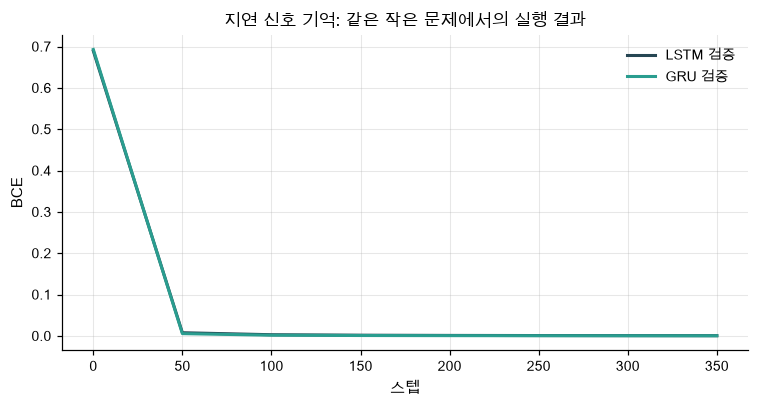

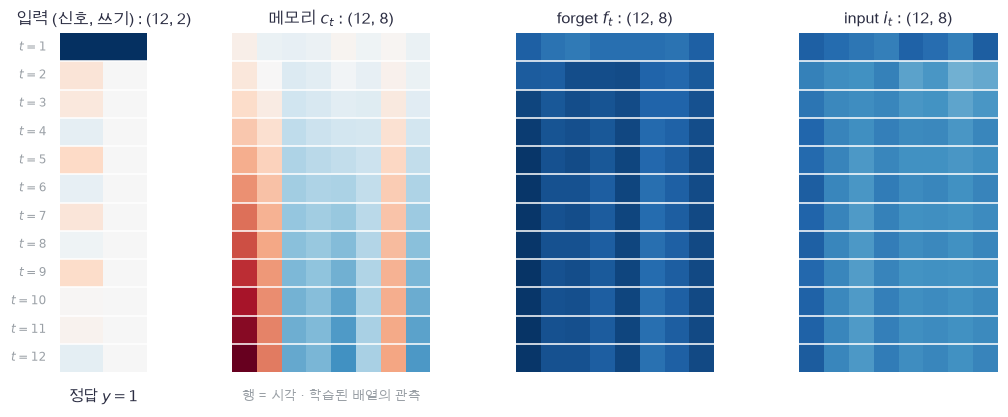

In [44]:
# 쓰는 것: gated_forward (5절) · X_valid, y_valid, trained (6절 학습 셀). 그림용: 검증 곡선과 학습된 LSTM의 게이트 띠
plot_curves(trained["LSTM"][2]["step"],
            {f"{kind} 검증": result[2]["valid"] for kind, result in trained.items()},
            title="지연 신호 기억: 같은 작은 문제에서의 실행 결과", ylabel="BCE")
p_lstm = trained["LSTM"][0]
Hs, Cs, caches = gated_forward(X_valid[:1], p_lstm, "LSTM")         # 검증 시퀀스 하나
forget = np.stack([cache[2][0] for cache in caches])                 # (T, H): 시각별 forget gate (캐시의 세 번째)
inputs = np.stack([cache[3][0] for cache in caches])                 # (T, H): 시각별 input gate (네 번째)
plot_gate_traces(X_valid[0], Cs[0], forget, inputs, y_valid[0])

🔍 **확인** · 두 구조 모두 검증 BCE가 0.1 아래로 내려가고 정확도가 90%를 넘습니다. 아래 띠는 학습된 LSTM이 검증 시퀀스 하나를 읽는 동안의 입력·메모리·두 게이트입니다.
게이트 그림은 학습된 배열의 관측입니다. 모든 좌표가 같은 시점에 완전히 열리거나 닫힐 필요는 없습니다. 특정 좌표에 '기억 뉴런'이라는 의미를 붙이기 전에 입력 부호·잡음·길이를 바꾸어 같은 반응이 유지되는지 확인해야 합니다.

### ✏️ 연습 6 · 마지막 상태에만 붙는 head

시퀀스 전체의 상태 `H` `(N, T, H)`에서 마지막 시각의 상태에만 선형 head를 붙여 `logits` `(N, 1)`을 만들고, 손실에서 온 `dz` `(N, 1)`를 head를 거꾸로 지나 `dH`의 마지막 시각 자리에만 넣는 두 줄을 채우세요. 나머지 시각의 `dH`는 0인 채로 두어야 5절의 backward가 그 기울기를 시간을 거슬러 첫 시각까지 보냅니다.

In [45]:
def exercise_last_state_head(H, head, dz):
    """연습 6: 마지막 상태에만 붙는 head의 forward와 backward. H: (N, T, H), head: {"W": (H, 1), "b": (1,)}, dz: (N, 1) → (logits: (N, 1), dH: (N, T, H))."""
    assert H.shape[2] == head["W"].shape[0], "head W의 행 수는 상태 폭 H여야 합니다"
    assert dz.shape == (H.shape[0], 1), "dz는 logit과 같은 (N, 1)이어야 합니다"
    dH = np.zeros_like(H)                                   # (N, T, H): 마지막 시각 말고는 상류 기울기가 0
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 마지막 시각의 상태에 선형 head를 붙인 logits (N, 1)과, dz 를 head를 거꾸로 지나 dH 의 마지막 시각 자리에만 넣기
    ### 힌트: 6절 memory_loss 의 logits 줄과 dH[:, -1] 줄입니다. 선형층 backward에서 입력의 기울기는 dz @ Wᵀ 입니다.
    raise NotImplementedError
    return logits, dH

In [46]:
def check_last_state_head(candidate):
    """손계산 하나와 6절 예시 두 시퀀스에서 본문 memory_loss와 비교합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: demo_X, demo_y (6절 예시 셀) · init_gates (4절) · gated_forward (5절) · memory_loss (6절)
    H_a = np.zeros((2, 3, 2))                                                 # (N, T, H): 마지막 시각만 0이 아님
    H_a[:, -1] = [[1., 2.], [0., -1.]]
    head_a = {"W": np.array([[0.5], [1.]]), "b": np.array([0.25])}
    logits_a, dH_a = candidate(H_a, head_a, np.array([[0.1], [-0.2]]))
    assert logits_a.shape == (2, 1), f"logit의 모양은 (N, 1) = (2, 1)이어야 하는데 {logits_a.shape}입니다"
    np.testing.assert_allclose(logits_a, [[2.75], [-0.75]])                   # 검산: [1·0.5 + 2·1, 0·0.5 + (−1)·1] + 0.25
    np.testing.assert_allclose(dH_a[:, -1], [[0.05, 0.1], [-0.1, -0.2]])      # 검산: dz · Wᵀ = [0.1, −0.2]ᵀ [0.5, 1]
    np.testing.assert_allclose(dH_a[:, :-1], 0.)                              # 검산: 마지막 시각 말고는 0
    p_c = init_gates("LSTM", 2, 4, 78)
    rng_c = np.random.default_rng(79)
    head_c = {"W": rng_c.normal(size=(4, 1)) / 2., "b": np.zeros(1)}
    H_c, _, _ = gated_forward(demo_X, p_c, "LSTM")
    logits_c, _ = candidate(H_c, head_c, np.zeros((2, 1)))
    np.testing.assert_allclose(logits_c[:, 0], memory_loss(demo_X, np.array(demo_y), p_c, head_c, "LSTM")[1])   # 검산: 본문 memory_loss의 logit
    print("마지막 상태의 head: 손계산·memory_loss 와 일치합니다.")

run_check(check_last_state_head, exercise_last_state_head, hint="logits = H[:, -1] @ head[\"W\"] + head[\"b\"] · dH[:, -1] = dz @ head[\"W\"].T")

☐ exercise_last_state_head: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: logits = H[:, -1] @ head["W"] + head["b"] · dH[:, -1] = dz @ head["W"].T


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
logits = H[:, -1] @ head["W"] + head["b"]
dH[:, -1] = dz @ head["W"].T
```

</details>

## ✏️ 7. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · 메모리 갱신과 출력 (1절)

게이트 `f, i, o`, 이전 메모리 `cprev`, 후보 `g`에서 새 메모리 `c`와 출력 `h`를 만드는 두 줄을 채우세요.

In [47]:
def exercise_lstm_memory(f, cprev, i, g, o):
    """연습 A: 메모리 갱신과 출력. f, cprev, i, g, o: 모두 (N, H) → (h, c: (N, H))."""
    assert f.shape == cprev.shape == i.shape == g.shape == o.shape, "다섯 배열은 모두 같은 모양 (N, H)이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: c = f ⊙ cprev + i ⊙ g, h = o ⊙ tanh(c)   (⊙ 는 원소별 곱 *)
    ### 힌트: 1절 lstm_step 의 마지막 두 줄입니다.
    raise NotImplementedError
    return h, c

In [48]:
def check_lstm_memory(candidate):
    """1절 손계산과 본문 lstm_step의 캐시로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: lstm_step (1절)
    one = np.ones((1, 1))
    h_a, c_a = candidate(0.5 * one, 0.2 * one, 0.5 * one, 0.8 * one, 0.5 * one)          # 1절 손계산
    np.testing.assert_allclose(c_a, 0.5)                                                   # 검산: c = 0.5·0.2 + 0.5·0.8
    np.testing.assert_allclose(h_a, 0.5 * np.tanh(0.5))                                    # 검산: h = o·tanh(c)
    rng_c = np.random.default_rng(71)
    x_c, h0_c, c0_c = [rng_c.normal(size=(2, 2)) * 0.3 for _ in range(3)]
    p_c = {"W": rng_c.normal(size=(4, 8)) * 0.3, "b": rng_c.normal(size=8) * 0.2}
    h_ref, c_ref, cache_ref = lstm_step(x_c, h0_c, c0_c, p_c)
    u_c, cprev_c, f_c, i_c, o_c, g_c, _, _ = cache_ref                                     # 캐시를 풀어 게이트를 꺼냄
    h_b, c_b = candidate(f_c, cprev_c, i_c, g_c, o_c)
    np.testing.assert_allclose(h_b, h_ref)                                                 # 검산: 본문 함수의 h
    np.testing.assert_allclose(c_b, c_ref)                                                 # 검산: 본문 함수의 c
    print("메모리 갱신: 손계산·lstm_step 과 일치합니다.")

run_check(check_lstm_memory, exercise_lstm_memory, hint="c = f * cprev + i * g; h = o * np.tanh(c)")

☐ exercise_lstm_memory: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: c = f * cprev + i * g; h = o * np.tanh(c)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
c = f * cprev + i * g
h = o * np.tanh(c)
```

</details>

### ✏️ 연습 B · c로 모이는 두 기울기 (2절)

상류 `dh`, 다음 시각에서 온 `dc_future`, 출력 게이트 `o`, 메모리 `c`에서 $dc$를 만드는 한 줄을 채우세요.

In [49]:
def exercise_dc(dh, dc_future, o, c):
    """연습 B: c로 모이는 두 기울기의 합. dh, dc_future, o, c: 모두 (N, H) → dc: (N, H)."""
    assert dh.shape == dc_future.shape == o.shape == c.shape, "네 배열은 모두 같은 모양 (N, H)이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: dc = 미래에서 온 dc_future 에, h = o·tanh(c) 를 거쳐 온 dh ⊙ o ⊙ (1 − tanh(c)²) 를 더한 값
    ### 힌트: 2절 첫 식의 두 번째 항등식입니다.
    raise NotImplementedError
    return dc

In [50]:
def check_dc(candidate):
    """2절 손계산 표와 본문 lstm_step_backward의 dc_prev로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: back_dc (2절 손계산 셀) · lstm_step (1절) · lstm_step_backward (2절)
    one = np.ones((1, 1))
    np.testing.assert_allclose(candidate(one, one, 0.5 * one, 0.5 * one).item(), back_dc)        # 검산: 2절 손계산 표의 dc
    rng_c = np.random.default_rng(72)
    x_c, h0_c, c0_c = [rng_c.normal(size=(3, 2)) * 0.3 for _ in range(3)]
    p_c = {"W": rng_c.normal(size=(4, 8)) * 0.3, "b": np.zeros(8)}
    _, _, cache_ref = lstm_step(x_c, h0_c, c0_c, p_c)
    dh_c, dcf_c = rng_c.normal(size=(3, 2)), rng_c.normal(size=(3, 2))
    _, _, dcprev_ref, _ = lstm_step_backward(dh_c, dcf_c, cache_ref, p_c)
    np.testing.assert_allclose(candidate(dh_c, dcf_c, cache_ref[4], cache_ref[6]) * cache_ref[2], dcprev_ref)   # 검산: dc ⊙ f = 본문의 dc_prev (캐시의 o, c, f)
    print("dc: 손계산·lstm_step_backward 와 일치합니다.")

run_check(check_dc, exercise_dc, hint="dc = dc_future + dh * o * (1 - np.tanh(c) ** 2)")

☐ exercise_dc: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dc = dc_future + dh * o * (1 - np.tanh(c) ** 2)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dc = dc_future + dh * o * (1 - np.tanh(c) ** 2)
```

</details>

### ✏️ 연습 C · GRU의 섞기 (4절)

update gate `z`, 이전 상태 `hprev`, 후보 `g`에서 새 상태 `h`를 만드는 한 줄을 채우세요.

In [51]:
def exercise_gru_mix(z, hprev, g):
    """연습 C: GRU의 섞기. z, hprev, g: 모두 같은 모양 → h: 같은 모양."""
    assert z.shape == hprev.shape == g.shape, "세 배열은 같은 모양이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: h = z ⊙ hprev + (1 − z) ⊙ g
    ### 힌트: 4절 gru_step 의 마지막 줄입니다. z 가 클수록 이전 상태를 유지합니다.
    raise NotImplementedError
    return h

In [52]:
def check_gru_mix(candidate):
    """4절 그림의 다섯 점과 본문 gru_step의 캐시로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: mix_z, mix_hprev, mix_g, mix_h (4절 그림 셀) · gru_step, init_gates (4절)
    np.testing.assert_allclose(candidate(mix_z, np.full(5, mix_hprev), np.full(5, mix_g)), mix_h)      # 검산: 4절 그림의 다섯 점
    rng_c = np.random.default_rng(74)
    x_c, h0_c = rng_c.normal(size=(2, 2)), rng_c.normal(size=(2, 3))
    h_ref, cache_ref = gru_step(x_c, h0_c, init_gates("GRU", 2, 3, 75))
    np.testing.assert_allclose(candidate(cache_ref[3], cache_ref[2], cache_ref[5]), h_ref)             # 검산: 캐시의 z, hprev, g로 본문의 h
    print("GRU 섞기: 4절 그림·gru_step 과 일치합니다.")

run_check(check_gru_mix, exercise_gru_mix, hint="h = z * hprev + (1 - z) * g")

☐ exercise_gru_mix: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: h = z * hprev + (1 - z) * g


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
h = z * hprev + (1 - z) * g
```

</details>

### ✏️ 연습 D · logit에서 계산하는 이진 CE (6절)

logit `logits` $(N,1)$과 정답 `target` $(N,1)$에서 평균 손실과 logit의 기울기를 만드는 두 줄을 채우세요.

In [53]:
def exercise_bce_with_logits(logits, target):
    """연습 D: logit에서 계산하는 이진 CE. logits, target: (N, 1) → (loss: 숫자, dz: (N, 1))."""
    assert logits.shape == target.shape, "logit과 정답은 같은 모양이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: loss = mean(log(1 + e^z) − y z), dz = (sigmoid(z) − y) / N
    ### 힌트: np.logaddexp(0, logits) 가 log(1 + e^z) 입니다. sigmoid 는 1절에 있습니다.
    raise NotImplementedError
    return loss, dz

In [54]:
def check_bce_with_logits(candidate):
    """손계산 한 점과 중심차분으로 검사합니다. 통과하면 메시지를 출력합니다."""
    loss_a, dz_a = candidate(np.array([[0.]]), np.array([[1.]]))
    np.testing.assert_allclose(loss_a, np.log(2))                     # 검산: z = 0이면 log(1 + 1) − 0
    np.testing.assert_allclose(dz_a, [[-0.5]])                        # 검산: (σ(0) − 1)/1
    rng_c = np.random.default_rng(78)
    z_c, y_c = rng_c.normal(size=(5, 1)), (rng_c.random((5, 1)) > 0.5).astype(float)   # 무작위 logit과 0/1 정답

    def bce_scalar():
        """검사기용: 후보 함수의 손실값."""
        return float(candidate(z_c, y_c)[0])

    _, dz_c = candidate(z_c, y_c)
    numeric_c = numerical_gradient(bce_scalar, z_c)
    assert rel_error(dz_c, numeric_c) < 1e-6, "dz가 중심차분과 1e−6 안에서 같아야 합니다"
    print("이진 CE: 손계산·중심차분과 일치합니다.")

run_check(check_bce_with_logits, exercise_bce_with_logits, hint="loss = np.mean(np.logaddexp(0, logits) - target * logits); dz = (sigmoid(logits) - target) / len(target)")

☐ exercise_bce_with_logits: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: loss = np.mean(np.logaddexp(0, logits) - target * logits); dz = (sigmoid(logits) - target) / len(target)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
loss = np.mean(np.logaddexp(0, logits) - target * logits)
dz = (sigmoid(logits) - target) / len(target)
```

</details>

### 🔍 완성 예제 · 검사기가 잡는 오답과 길이 밖 평가

아래는 $c$의 상류 경로 $dc_{future}$를 잘라 버린 실제 오답입니다. 2절의 검사기가 거부해야 합니다.
이어서 학습한 모델을 추가 갱신 없이 길이 24의 새 데이터 `memory_data(64, 24, 703)`에 적용합니다. 짧은 길이의 학습 성공과 길이 밖 기억은 다른 질문입니다.

> **코드** · `try: … except AssertionError: … else: …`: 검사기가 assert로 멈추면 `except`로 가고(오답을 잡은 것), 멈추지 않으면 `else`로 갑니다. 여기서는 오답이 **잡혀야** 정상이므로 `else`에서 일부러 오류를 냅니다.

In [55]:
def wrong_drop_cell_gradient(dh, dc_future, cache, p):
    """일부러 틀린 backward: c의 상류 경로 dc_future를 0으로 잘라 버립니다. 인자·반환은 lstm_step_backward와 같습니다."""
    # 쓰는 것: lstm_step_backward (2절)
    return lstm_step_backward(dh, np.zeros_like(dc_future), cache, p)

In [56]:
# 쓰는 것: check_lstm_step (2절) · memory_data, memory_loss (6절) · trained (6절 학습 셀)
try:
    check_lstm_step(wrong_drop_cell_gradient)
except AssertionError:
    print("의도적 오답 검출: c의 별도 상류 기울기 누락")
else:
    raise AssertionError("검사기가 오답을 놓쳤습니다")
X_long, y_long = memory_data(64, 24, 703)                       # 길이 24의 새 데이터
for kind, (p, head, _, _) in trained.items():                   # 학습한 파라미터를 추가 갱신 없이 적용
    loss, z, *_ = memory_loss(X_long, y_long, p, head, kind)
    print(f"추가 갱신 없는 길이 24 {kind}: BCE {loss:.6f}, 정확도 {np.mean((z > 0) == y_long):.1%}")

의도적 오답 검출: c의 별도 상류 기울기 누락
추가 갱신 없는 길이 24 LSTM: BCE 0.000503, 정확도 100.0%
추가 갱신 없는 길이 24 GRU: BCE 0.000257, 정확도 100.0%


### ✏️ 준비도 질문 · 다음으로 가기 전, 네 가지를 따로 확인합니다

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

- **설명:** LSTM의 h·c와 세 게이트, GRU의 reset·update가 실제로 곱하는 대상을 설명할 수 있나요? → 1·4절
- **수식:** c로 들어온 두 미분을 더하고 GRU의 직접·후보·게이트 경로를 모두 셀 수 있나요? → 2·4절
- **구현:** 네 묶음의 순서와 concat/split 축을 맞추며 초기 상태까지 미분할 수 있나요? → 1·2·5절
- **변형:** forget bias를 1에서 0으로 바꾸면 초기 유지량이 $\sigma(1)\approx0.731$에서 0.5로 바뀝니다. 지연 길이와 함께 바꿔 보고, 직접 경로의 곱과 전체 미분을 구분할 수 있나요? → 3·6절

다음은 [08 Attention](08_attention.ipynb)입니다. 과거를 한 상태에만 넣는 대신, 필요한 위치를 점수로 선택해 읽습니다.

📎 [LSTM 원전, Hochreiter·Schmidhuber 1997](https://www.bioinf.jku.at/publications/older/2604.pdf), [LSTM 변형과 수식, Greff 등](https://arxiv.org/abs/1503.04069), [GRU, Cho 등 2.3절](https://arxiv.org/abs/1406.1078)을 참고할 수 있습니다. 여기서는 위에서 명시한 peephole 없는 LSTM과 reset-before GRU를 구현했습니다.